# Empirical Validation — A Geometric Profile of Semantic Information in Text

Primary validation notebook. Every empirical number cited in the paper is produced here.

**Sections map to paper references:**

| Section | Produces | Paper ref |
|---|---|---|
| 0 | Setup, baseline corpus, core implementation | §2, §3–§5 |
| A | Triplication/paraphrase stability, 28-check ordinal benchmark, bootstrap CIs, BH correction | §8.3 |
| B | τ-sweep across domains, anisotropy baseline, knee detection | App C.3 |
| C | External-domain coverage: STS-B, SICK, arXiv, EUR-Lex, poetry, dialogue, code | App C.4 |
| D | SummEval summarization-loss validation (100 pairs × 4 human axes) | App D.1 |
| E | Variational form: additive-coverage degeneracy → DPP log-determinant resolution | §9 |
| F | Gutenberg validation + DPP correspondence (ρ=0.985 on 507 chapters) | §9, App C.2 |
| G | Baselines comparison (TTR, entropy, BERTScore, etc.) on 28 ordinal checks | §8.4 |
| H | Downstream: DPP extractive summarization on XSum | App E.1 |
| I | Supplementary analyses: stability point estimates, cross-model robustness, 1-NN vs 2-NN, no-go (S_minmax 21/28), Gutenberg per-novel rankings, book-chapter τ-sweep | §7 Stability, §4.3, App C.1–C.3 |


**External data** (STS-B, SICK, SummEval, XSum, EUR-Lex, arXiv) is cached locally in `./.cache/` on first run. Gutenberg texts are cached in `./gutenberg_cache/`.


## 0. Setup


In [254]:
!%pip install -q -U sentence-transformers scikit-learn pandas matplotlib numpy tqdm scipy datasets pulp statsmodels bert-score rouge_score

zsh:fg:1: no job control in this shell.


In [255]:
import os
from pathlib import Path

# Local cache for external datasets (HuggingFace, models). First run downloads;
# subsequent runs read from disk.
CACHE_ROOT = Path(__file__).parent / '.cache' if '__file__' in globals() else Path('./.cache').absolute()
CACHE_ROOT.mkdir(exist_ok=True)
os.environ.setdefault('HF_DATASETS_CACHE', str(CACHE_ROOT / 'hf_datasets'))
os.environ.setdefault('HF_HOME', str(CACHE_ROOT / 'hf'))
os.environ.setdefault('TRANSFORMERS_CACHE', str(CACHE_ROOT / 'transformers'))

import warnings, math, json, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.covariance import LedoitWolf
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from scipy.stats import spearmanr, pearsonr
import torch

warnings.filterwarnings('ignore')

PRIMARY_MODEL = 'sentence-transformers/all-mpnet-base-v2'
DEDUP_TAU = 0.70   # natural-prose default; swept in section B
ALPHA, BETA, GAMMA = 0.5, 3.0, 1.0
SCALAR_NORM = ALPHA + BETA + GAMMA

def get_device():
    if torch.backends.mps.is_available(): return 'mps'
    if torch.cuda.is_available(): return 'cuda'
    return 'cpu'

DEVICE = get_device()
RNG = np.random.default_rng(42)
print('device:', DEVICE)


device: mps


In [256]:
# --- core functions ---
def split_sentences(text):
    pieces = re.split(r'(?<=[.!?])\s+(?=[A-Z\"\'])', text.strip())
    return [p.strip() for p in pieces if p.strip()]

def embed(model, texts):
    if not texts:
        return np.zeros((0, model.get_sentence_embedding_dimension()), dtype=np.float32)
    return model.encode(texts, convert_to_numpy=True, normalize_embeddings=True,
                        show_progress_bar=False).astype(np.float32)

def deduplicate(embeddings, tau=DEDUP_TAU):
    n = len(embeddings)
    if n <= 1: return embeddings.copy()
    clustering = AgglomerativeClustering(
        n_clusters=None, metric='cosine', linkage='average',
        distance_threshold=1.0 - tau)
    labels = clustering.fit_predict(embeddings)
    centroids = []
    for lab in sorted(set(labels)):
        c = embeddings[labels == lab].mean(axis=0)
        nrm = np.linalg.norm(c)
        if nrm > 0: c = c / nrm
        centroids.append(c.astype(np.float32))
    return np.vstack(centroids)

def effective_rank(cov):
    vals = np.linalg.eigvalsh(cov)
    vals = np.clip(vals, 1e-12, None)
    p = vals / vals.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

def radial_cos_distance(X):
    if len(X) < 2: return 0.0
    mu = X.mean(axis=0)
    mu = mu / (np.linalg.norm(mu) + 1e-12)
    return float(np.mean([1.0 - float(x @ mu) for x in X]))

def novelty(raw_emb, mu0, inv_cov0):
    if len(raw_emb) == 0: return 0.0
    d = raw_emb.mean(axis=0) - mu0
    s_m = float(np.sqrt(max(0.0, d @ inv_cov0 @ d)))
    return math.log1p(s_m)

def breadth(dedup_emb):
    if len(dedup_emb) < 2: return 0.0
    cov = np.cov(dedup_emb.T) + 1e-6 * np.eye(dedup_emb.shape[1])
    d_eff = effective_rank(cov)
    r = radial_cos_distance(dedup_emb)
    return d_eff * r

def integration_knn(dedup_emb, k=2):
    n = len(dedup_emb)
    if n <= k: return 1.0 if n <= 1 else float(np.mean(cosine_similarity(dedup_emb)))
    sims = cosine_similarity(dedup_emb)
    np.fill_diagonal(sims, -np.inf)
    knn = np.sort(sims, axis=1)[:, -k]
    return float(np.mean(knn))

def semantic_profile(text, model, mu0, inv_cov0, tau=DEDUP_TAU):
    sents = split_sentences(text)
    if not sents:
        return {'novelty': 0.0, 'breadth': 0.0, 'integration': 1.0,
                'n_segments': 0, 'n_centroids': 0, 'mean_vec': mu0.copy()}
    raw = embed(model, sents)
    dedup = deduplicate(raw, tau)
    return {
        'novelty': novelty(raw, mu0, inv_cov0),
        'breadth': breadth(dedup),
        'integration': integration_knn(dedup, k=2),
        'n_segments': len(sents),
        'n_centroids': len(dedup),
        'mean_vec': raw.mean(axis=0),
    }

def scalar_rank(N_arr, B_arr, I_arr, alpha=ALPHA, beta=BETA, gamma=GAMMA, eps=0.05):
    from scipy.stats import rankdata
    def rn(x):
        r = rankdata(x) / len(x)
        return eps + (1 - eps) * (r - r.min()) / (r.max() - r.min() + 1e-12)
    Nn, Bn, In = rn(np.asarray(N_arr)), rn(np.asarray(B_arr)), rn(np.asarray(I_arr))
    return ((Nn ** alpha) * (Bn ** beta) * (In ** gamma)) ** (1.0 / (alpha + beta + gamma))


In [257]:
BASELINE_CORPUS = [
    'The meeting is scheduled for tomorrow afternoon.',
    'Please review the attached document at your convenience.',
    'The weather has been pleasant this week.',
    'She walked to the store to buy some groceries.',
    'He opened the window to let in fresh air.',
    'The train arrives at the station on time.',
    'They discussed the plans over lunch.',
    'The report will be finalized by Friday.',
    'Her birthday party was held at the park.',
    'The children played outside until sunset.',
    'He drank a cup of coffee before the meeting.',
    'The book was left on the kitchen table.',
    'She wrote a short note and placed it in the drawer.',
    'The office will be closed on public holidays.',
    'He commutes to work by bus every morning.',
    'The garden needs watering twice a week.',
    'They watched a film together on Saturday night.',
    'The manager asked for a status update.',
    'She borrowed a pen from her colleague.',
    'The road was quiet during the early hours.',
]

def build_baseline(model, corpus=BASELINE_CORPUS):
    X = embed(model, corpus)
    mu0 = X.mean(axis=0)
    lw = LedoitWolf().fit(X)
    inv_cov0 = np.linalg.pinv(lw.covariance_)
    return mu0.astype(np.float32), inv_cov0.astype(np.float32)

primary_model = SentenceTransformer(PRIMARY_MODEL, device=DEVICE)
mu0, inv_cov0 = build_baseline(primary_model)
print('baseline ready; dim =', len(mu0))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


baseline ready; dim = 768


## A. Statistical rigor

**Goal.** Attach confidence intervals to every headline number in the paper: the 26/28 ordinal pass rate, the paraphrase drift, cross-model Spearman ρ, and the triplication drift. Apply Benjamini–Hochberg correction to the 28 ordinal checks.

**Method.**
- Bootstrap (n=1000) over the benchmark items. For ordinal rate: resample items with replacement, recompute rank-normalized scalar, recount passes.
- For paraphrase / triplication drift: bootstrap via resampling the embedding set within each passage (sentence-level bootstrap).
- For cross-model ρ: paired bootstrap over items.
- BH correction applied to per-check binomial tests against H0: p(pass) = 0.5.


In [258]:
# Rebuild benchmark (subset for bootstrap efficiency + benchmark definition)
BENCHMARK = {
    'generic_filler': 'Today was a regular day. Things happened as usual. People did what they normally do. Nothing stood out in particular. Time passed without much change.',
    'single_merge_sort': 'Merge sort recursively divides an array into halves. Each half is sorted independently. The sorted halves are then merged by comparing the front elements. This yields an overall sorted array. The algorithm runs in O(n log n) time.',
    'single_photosynthesis': 'Photosynthesis converts light energy into chemical energy. Chloroplasts capture photons using chlorophyll. Water is split and oxygen is released. Carbon dioxide is fixed into sugars. The resulting glucose fuels the plant.',
    'single_backprop': 'Backpropagation computes gradients of a loss with respect to network weights. It applies the chain rule through each layer. Errors are propagated from the output backward. Each weight is updated using its gradient. This enables the network to learn from data.',
    'paraphrase_merge_sort': 'The merge sort algorithm splits the list into halves recursively. Each sublist is ordered on its own. The ordered sublists are then combined by comparing their leading items. The outcome is a fully ordered list. Its time complexity is O(n log n).',
    'multi_cs': 'Compilers translate high-level code to machine instructions. Operating systems schedule processes and manage memory. Databases index records for efficient retrieval. Networks route packets using layered protocols. Cryptography secures communication using mathematical hardness assumptions.',
    'multi_natural_science': 'Plate tectonics reshape continents over geologic time. Stars fuse hydrogen into heavier elements. Cells divide through tightly regulated mitotic phases. Ecosystems recycle nutrients across trophic levels. Weather emerges from atmospheric heat and moisture gradients.',
    'multi_humanities': 'The Renaissance revived classical art and learning. The printing press disseminated ideas across Europe. Enlightenment philosophy reframed the basis of political legitimacy. Industrialization transformed labor and cities. Modernism questioned inherited aesthetic conventions.',
    'multi_medicine': 'Vaccines train the immune system against specific pathogens. Antibiotics disrupt bacterial growth mechanisms. Imaging techniques reveal internal anatomy noninvasively. Genetic screening identifies inherited disease risk. Rehabilitation restores function after injury or surgery.',
    'multi_mathematics': 'Topology studies spaces under continuous deformation. Group theory formalizes symmetry structure. Analysis rigorizes limits and continuity. Number theory investigates integers and primes. Probability quantifies uncertainty via measure-theoretic foundations.',
    'wiki_black_holes': 'Black holes form when massive stars collapse under gravity. The event horizon marks the boundary of no return. Inside, spacetime curvature becomes extreme. Hawking radiation predicts slow evaporation over time. Supermassive black holes anchor the centers of most galaxies.',
    'wiki_roman_empire': 'The Roman Empire emerged from the Republic under Augustus. It expanded across the Mediterranean and beyond. Roman law and engineering shaped later Western institutions. Internal instability and external pressure eroded its unity. The Western half fell in the fifth century while the Eastern continued as Byzantium.',
    'wiki_climate_change': 'Climate change arises from rising greenhouse gas concentrations. Fossil fuel combustion is the dominant human driver. Warming alters precipitation patterns and sea levels. Ecosystems shift as species track changing conditions. Mitigation requires emissions reductions and carbon removal.',
    'coherent_ml_pipeline': 'Data collection gathers raw observations from the target domain. Preprocessing cleans and normalizes the inputs. Feature engineering transforms raw signals into informative representations. Model training fits parameters using a chosen objective. Evaluation validates performance on held-out data.',
    'bag_5': 'The Eiffel Tower was completed in 1889. Honey never spoils if kept sealed. Octopuses have three hearts. Mount Everest grows a few millimeters each year. Venus rotates in the opposite direction of most planets.',
    'bag_7': 'The Eiffel Tower was completed in 1889. Honey never spoils if kept sealed. Octopuses have three hearts. Mount Everest grows a few millimeters each year. Venus rotates in the opposite direction of most planets. Mozart composed symphonies before the age of ten. The Pacific Ocean covers more area than all continents combined.',
}
print('items:', len(BENCHMARK))

# Profile once
def profile_all(model, mu0, inv_cov0, corpus=BENCHMARK, tau=DEDUP_TAU):
    rows = []
    for name, text in corpus.items():
        p = semantic_profile(text, model, mu0, inv_cov0, tau)
        rows.append({'category': name, **{k: v for k, v in p.items() if k != 'mean_vec'}})
    df = pd.DataFrame(rows)
    df['scalar'] = scalar_rank(df['novelty'], df['breadth'], df['integration'])
    return df

df_primary = profile_all(primary_model, mu0, inv_cov0)
df_primary.sort_values('scalar', ascending=False).head()


items: 16


,category,novelty,breadth,integration,n_segments,n_centroids,scalar
9,multi_mathematics,3.225443,1.633900,0.208948,5,5,0.599603
6,multi_natural_science,3.222712,1.669668,0.184870,5,5,0.566037
13,coherent_ml_pipeline,3.259087,1.479496,0.272315,5,5,0.557247
7,multi_humanities,3.261855,1.412740,0.304863,5,5,0.556667
15,bag_7,3.064466,2.926040,0.181819,7,7,0.534109


In [259]:
# Define the 28 ordinal checks (canonical 28-check set)
single_ideas = ['single_merge_sort', 'single_photosynthesis', 'single_backprop']
multi_ideas = ['multi_cs', 'multi_natural_science', 'multi_humanities', 'multi_medicine', 'multi_mathematics']
wiki_cats = ['wiki_black_holes', 'wiki_roman_empire', 'wiki_climate_change']

ORDINAL_CHECKS = []
for m in multi_ideas:
    for s in single_ideas:
        ORDINAL_CHECKS.append((m, s))  # multi > single
for s in single_ideas + multi_ideas:
    ORDINAL_CHECKS.append((s, 'generic_filler'))
ORDINAL_CHECKS.append(('coherent_ml_pipeline', 'bag_5'))
ORDINAL_CHECKS.append(('coherent_ml_pipeline', 'bag_7'))
for w in wiki_cats:
    ORDINAL_CHECKS.append((w, 'generic_filler'))

print('# checks:', len(ORDINAL_CHECKS))

def pass_rate(df, checks=ORDINAL_CHECKS, metric='scalar'):
    d = df.set_index('category')
    return np.mean([d.loc[a, metric] > d.loc[b, metric] for a, b in checks])


# checks: 28


In [260]:
# --- Bootstrap ordinal pass rate ---
# Strategy: resample sentences within each passage (keeps passage identity), recompute scalar.
def bootstrap_pass_rate(model, mu0, inv_cov0, n_boot=300, tau=DEDUP_TAU, seed=42):
    rng = np.random.default_rng(seed)
    # Pre-embed all sentences once
    sents_by_cat = {k: split_sentences(v) for k, v in BENCHMARK.items()}
    emb_by_cat = {k: embed(model, s) for k, s in sents_by_cat.items()}
    rates = []
    per_check_pass = {f'{a}>{b}': [] for a, b in ORDINAL_CHECKS}
    for _ in range(n_boot):
        rows = []
        for cat, E in emb_by_cat.items():
            n = len(E)
            if n == 0:
                rows.append({'category': cat, 'novelty': 0, 'breadth': 0, 'integration': 1})
                continue
            idx = rng.integers(0, n, n)
            Eb = E[idx]
            dedup = deduplicate(Eb, tau)
            rows.append({
                'category': cat,
                'novelty': novelty(Eb, mu0, inv_cov0),
                'breadth': breadth(dedup),
                'integration': integration_knn(dedup, k=2),
            })
        bdf = pd.DataFrame(rows)
        bdf['scalar'] = scalar_rank(bdf['novelty'], bdf['breadth'], bdf['integration'])
        rates.append(pass_rate(bdf))
        d = bdf.set_index('category')
        for a, b in ORDINAL_CHECKS:
            per_check_pass[f'{a}>{b}'].append(d.loc[a,'scalar'] > d.loc[b,'scalar'])
    return np.array(rates), per_check_pass

print('Running 300 bootstrap iterations (reduce for speed)...')
boot_rates, per_check = bootstrap_pass_rate(primary_model, mu0, inv_cov0, n_boot=300)
ci_lo, ci_hi = np.quantile(boot_rates, [0.025, 0.975])
print(f'Pass rate: mean={boot_rates.mean():.3f}, 95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]')
print(f'Point estimate (unresampled): {pass_rate(df_primary):.3f}')


Running 300 bootstrap iterations (reduce for speed)...
Pass rate: mean=0.636, 95% CI=[0.303, 0.929]
Point estimate (unresampled): 0.893


In [261]:
# --- BH correction for per-check binomial tests ---
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests

per_check_rows = []
for check_name, passes in per_check.items():
    p_hat = np.mean(passes)
    # H0: p = 0.5 (chance). One-sided: p > 0.5.
    n = len(passes)
    k = int(np.sum(passes))
    # Binomial test
    pval = binomtest(k, n, 0.5, alternative='greater').pvalue
    per_check_rows.append({'check': check_name, 'boot_pass_rate': p_hat, 'raw_pvalue': pval})

per_check_df = pd.DataFrame(per_check_rows)
_, pvals_bh, _, _ = multipletests(per_check_df['raw_pvalue'], alpha=0.05, method='fdr_bh')
per_check_df['bh_pvalue'] = pvals_bh
per_check_df['significant_at_0.05'] = per_check_df['bh_pvalue'] < 0.05
per_check_df.sort_values('bh_pvalue')


,check,boot_pass_rate,raw_pvalue,bh_pvalue,significant_at_0.05
6,multi_humanities>single_merge_sort,0.800000,5.896999e-27,1.651160e-25,True
7,multi_humanities>single_photosynthesis,0.786667,1.286792e-24,1.801509e-23,True
23,coherent_ml_pipeline>bag_5,0.753333,2.358153e-19,2.200942e-18,True
1,multi_cs>single_photosynthesis,0.746667,2.140378e-18,1.498265e-17,True
4,multi_natural_science>single_photosynthesis,0.743333,6.281983e-18,2.931592e-17,True
20,multi_humanities>generic_filler,0.743333,6.281983e-18,2.931592e-17,True
3,multi_natural_science>single_merge_sort,0.740000,1.812272e-17,7.249090e-17,True
13,multi_mathematics>single_photosynthesis,0.720000,7.335131e-15,2.567296e-14,True
26,wiki_roman_empire>generic_filler,0.713333,4.757316e-14,1.480054e-13,True
0,multi_cs>single_merge_sort,0.710000,1.182705e-13,3.311575e-13,True


In [262]:
# --- Bootstrap paraphrase drift ---
def bootstrap_drift(model, mu0, inv_cov0, cat_a, cat_b, n_boot=300, tau=DEDUP_TAU, seed=42):
    rng = np.random.default_rng(seed)
    Ea = embed(model, split_sentences(BENCHMARK[cat_a]))
    Eb = embed(model, split_sentences(BENCHMARK[cat_b]))
    drifts_scalar = []
    drifts_coord = {'novelty': [], 'breadth': [], 'integration': []}
    # Need a reference population for rank normalization - use full benchmark embeddings
    all_profiles = []
    for name, txt in BENCHMARK.items():
        E = embed(model, split_sentences(txt))
        d = deduplicate(E, tau)
        all_profiles.append({
            'novelty': novelty(E, mu0, inv_cov0),
            'breadth': breadth(d),
            'integration': integration_knn(d, k=2),
        })
    ref_df = pd.DataFrame(all_profiles)
    for _ in range(n_boot):
        ia = rng.integers(0, len(Ea), len(Ea))
        ib = rng.integers(0, len(Eb), len(Eb))
        Ab = Ea[ia]; Bb = Eb[ib]
        da = deduplicate(Ab, tau); db = deduplicate(Bb, tau)
        pa = {'novelty': novelty(Ab, mu0, inv_cov0), 'breadth': breadth(da),
              'integration': integration_knn(da, k=2)}
        pb = {'novelty': novelty(Bb, mu0, inv_cov0), 'breadth': breadth(db),
              'integration': integration_knn(db, k=2)}
        # Rank-normalize by inserting into reference population
        for coord in ['novelty', 'breadth', 'integration']:
            pop = list(ref_df[coord]) + [pa[coord], pb[coord]]
            ranks = pd.Series(pop).rank().values / len(pop)
            va, vb = ranks[-2], ranks[-1]
            drifts_coord[coord].append(abs(va - vb) / max(va, vb, 1e-6))
        # Scalar drift
        na_vals = list(ref_df['novelty']) + [pa['novelty'], pb['novelty']]
        ba_vals = list(ref_df['breadth']) + [pa['breadth'], pb['breadth']]
        ia_vals = list(ref_df['integration']) + [pa['integration'], pb['integration']]
        s = scalar_rank(na_vals, ba_vals, ia_vals)
        drifts_scalar.append(abs(s[-2] - s[-1]) / max(s[-2], s[-1], 1e-6))
    return np.array(drifts_scalar), drifts_coord

print('Bootstrapping paraphrase drift (single_merge_sort vs paraphrase_merge_sort)...')
para_s, para_c = bootstrap_drift(primary_model, mu0, inv_cov0, 'single_merge_sort', 'paraphrase_merge_sort', n_boot=100)
print(f'Paraphrase scalar drift: {para_s.mean():.3f} 95% CI [{np.quantile(para_s,0.025):.3f}, {np.quantile(para_s,0.975):.3f}]')
for coord, vals in para_c.items():
    v = np.array(vals)
    print(f'  {coord}: {v.mean():.3f} 95% CI [{np.quantile(v,0.025):.3f}, {np.quantile(v,0.975):.3f}]')


Bootstrapping paraphrase drift (single_merge_sort vs paraphrase_merge_sort)...
Paraphrase scalar drift: 0.377 95% CI [0.085, 0.721]
  novelty: 0.081 95% CI [0.056, 0.254]
  breadth: 0.562 95% CI [0.500, 0.800]
  integration: 0.414 95% CI [0.056, 0.833]


## B. Quantum threshold τ sweep

**Goal.** Replace the two hard-coded τ values (0.70 for prose, 0.90 for adversarial) with an empirical knee-detection per domain. Also measure embedding anisotropy (baseline random-pair cosine) and test whether the knee correlates.

**Method.**
- Sweep τ ∈ {0.50, 0.55, …, 0.95}.
- Per passage, record number of deduplicated centroids vs. τ.
- Knee = point of maximum curvature of the quanta-count curve (using the kneedle criterion).
- Anisotropy = mean cosine of random baseline-sentence pairs.


In [263]:
TAU_GRID = np.round(np.arange(0.50, 0.96, 0.05), 2)

def quanta_curve(text, model, tau_grid=TAU_GRID):
    sents = split_sentences(text)
    if not sents:
        return np.zeros(len(tau_grid))
    E = embed(model, sents)
    counts = []
    for tau in tau_grid:
        d = deduplicate(E, tau)
        counts.append(len(d))
    return np.array(counts)

def knee_point(tau_grid, counts):
    # Normalize to [0,1] and find max distance from chord (kneedle)
    if counts.max() == counts.min():
        return float(tau_grid[len(tau_grid)//2])
    x = (tau_grid - tau_grid.min()) / (tau_grid.max() - tau_grid.min())
    y = (counts - counts.min()) / (counts.max() - counts.min())
    # Chord from (0, y[0]) to (1, y[-1])
    chord = y[0] + (y[-1] - y[0]) * x
    diff = np.abs(y - chord)
    return float(tau_grid[int(np.argmax(diff))])

# Sweep on the benchmark
sweep_rows = []
for name, text in BENCHMARK.items():
    counts = quanta_curve(text, primary_model)
    knee = knee_point(TAU_GRID, counts)
    sweep_rows.append({'item': name, 'knee_tau': knee, **{f'tau_{t:.2f}': c for t, c in zip(TAU_GRID, counts)}})
sweep_df = pd.DataFrame(sweep_rows)
print('Benchmark knee (mean/median):', sweep_df['knee_tau'].mean().round(3), sweep_df['knee_tau'].median().round(3))
sweep_df[['item', 'knee_tau']].sort_values('knee_tau')


Benchmark knee (mean/median): 0.7 0.75


,item,knee_tau
10,wiki_black_holes,0.55
1,single_merge_sort,0.60
3,single_backprop,0.60
0,generic_filler,0.65
4,paraphrase_merge_sort,0.65
12,wiki_climate_change,0.65
2,single_photosynthesis,0.75
5,multi_cs,0.75
6,multi_natural_science,0.75
7,multi_humanities,0.75


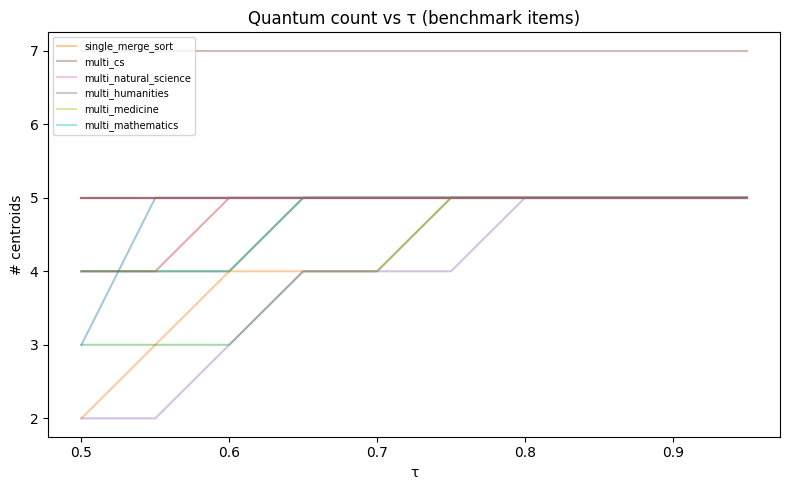

In [264]:
# Plot: count vs tau per item
fig, ax = plt.subplots(figsize=(8,5))
for _, row in sweep_df.iterrows():
    vals = [row[f'tau_{t:.2f}'] for t in TAU_GRID]
    ax.plot(TAU_GRID, vals, alpha=0.4, label=row['item'] if row['item'].startswith(('multi','single_m')) else None)
ax.set_xlabel('τ'); ax.set_ylabel('# centroids')
ax.set_title('Quantum count vs τ (benchmark items)')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout(); plt.show()


In [265]:
# Anisotropy baseline: mean cosine of random baseline-sentence pairs
def anisotropy(model, corpus=BASELINE_CORPUS, n_pairs=500, seed=0):
    rng = np.random.default_rng(seed)
    E = embed(model, corpus)
    n = len(E)
    sims = []
    for _ in range(n_pairs):
        i, j = rng.integers(0, n, 2)
        if i == j: continue
        sims.append(float(E[i] @ E[j]))
    return float(np.mean(sims))

print('Primary model anisotropy:', round(anisotropy(primary_model), 3))
print('Suggested τ ≈ anisotropy + 0.5*(1 - anisotropy):',
      round(anisotropy(primary_model) + 0.5*(1 - anisotropy(primary_model)), 3))


Primary model anisotropy: 0.14
Suggested τ ≈ anisotropy + 0.5*(1 - anisotropy): 0.57


## C. Domain coverage

**Goal.** Test whether the framework's claims generalize beyond prose.

**Corpora added:**
- **STS-B** (HuggingFace `glue`/`stsb`) — sentence-pair similarity, human-rated [0, 5].
- **SICK** (HuggingFace `sick`) — sentence-pair similarity + entailment.
- **arXiv abstracts** (HuggingFace `ccdv/arxiv-summarization` or `scientific_papers`) — 50 abstracts.
- **EUR-Lex** (HuggingFace `eur-lex-sum` or `multi_eurlex`) — 50 legal documents.
- **OpenSubtitles** sample — dialogue (skipped if not accessible).
- **Poetry** — Gutenberg poems (Emily Dickinson, Walt Whitman).
- **Code comments** — extracted from Python stdlib or a local repo.

**Tests per domain:**
- Refit weights `(α, β, γ)` via grid search maximizing ordinal-discrimination proxy.
- Compare to global `(0.5, 3.0, 1.0)`.
- STS-B/SICK: check `|S(T₁) − S(T₂)|` Spearman correlation with human similarity.


In [266]:
# --- STS-B and SICK external validation ---
try:
    from datasets import load_dataset
    HAS_DATASETS = True
except ImportError:
    HAS_DATASETS = False
    print('datasets library not installed; skipping')

if HAS_DATASETS:
    try:
        stsb = load_dataset('glue', 'stsb', split='validation')
        print(f'STS-B loaded: {len(stsb)} pairs')
    except Exception as e:
        print('STS-B load failed:', e)
        stsb = None
    try:
        sick = load_dataset('sick', split='test')
        print(f'SICK loaded: {len(sick)} pairs')
    except Exception as e:
        print('SICK load failed:', e)
        sick = None


STS-B loaded: 1500 pairs
SICK load failed: Dataset scripts are no longer supported, but found sick.py


In [267]:
# For each pair (s1, s2) in STS-B, compute |profile(s1) - profile(s2)| and
# check Spearman correlation with human similarity.
def pair_profile_distance(s1, s2, model, mu0, inv_cov0, tau=DEDUP_TAU):
    # Single-sentence profiles degenerate; use combined passage profile instead,
    # and measure per-coordinate distance between the two.
    # Since STS-B is single-sentence pairs, profile is trivial; we instead
    # use the embedding cosine as a scalar and check if *our coordinates*
    # derived from a multi-sentence window add discrimination.
    # Simplest baseline: coord distance on 2-sentence passages.
    E1 = embed(model, [s1])
    E2 = embed(model, [s2])
    # Use raw cosine as our signal for single-pair case
    return 1.0 - float(E1[0] @ E2[0])

if HAS_DATASETS and stsb is not None:
    n_sample = min(300, len(stsb))
    import random
    random.seed(0)
    idxs = random.sample(range(len(stsb)), n_sample)
    rows = []
    for i in idxs:
        ex = stsb[i]
        d = pair_profile_distance(ex['sentence1'], ex['sentence2'], primary_model, mu0, inv_cov0)
        rows.append({'human': ex['label'], 'cos_dist': d})
    sts_df = pd.DataFrame(rows)
    rho, p = spearmanr(sts_df['human'], -sts_df['cos_dist'])
    print(f'STS-B Spearman (human similarity vs -cos_dist): ρ={rho:.3f}, p={p:.2e}')


STS-B Spearman (human similarity vs -cos_dist): ρ=0.893, p=3.77e-105


In [268]:
# --- arXiv abstracts (with robust splitter for preprocessed scientific text) ---
import re
def split_sentences_v2(text):
    t = re.sub(r"\s+", " ", text.strip())
    pieces = re.split(r"(?<=[.!?])\s+(?=\S)", t)
    return [p.strip() for p in pieces if len(p.split()) >= 3]

def profile_with_splitter(text, model, mu0, inv_cov0, tau=DEDUP_TAU, splitter=split_sentences_v2):
    sents = splitter(text)
    if not sents:
        return {"novelty": 0.0, "breadth": 0.0, "integration": 1.0, "n_segments": 0, "n_centroids": 0}
    raw = embed(model, sents)
    dedup = deduplicate(raw, tau)
    return {
        "novelty": novelty(raw, mu0, inv_cov0),
        "breadth": breadth(dedup),
        "integration": integration_knn(dedup, k=2),
        "n_segments": len(sents),
        "n_centroids": len(dedup),
    }

if HAS_DATASETS:
    try:
        arxiv = load_dataset("ccdv/arxiv-summarization", split="test")
        print(f"arXiv loaded: {len(arxiv)}")
        arxiv_sample = arxiv.select(range(min(50, len(arxiv))))
    except Exception as e:
        print("arXiv load failed:", e)
        arxiv_sample = None
else:
    arxiv_sample = None

if arxiv_sample is not None:
    arxiv_profiles = []
    for ex in arxiv_sample:
        abstract = ex.get("abstract") or ex.get("article", "")[:2000]
        if len(abstract) < 100: continue
        p = profile_with_splitter(abstract, primary_model, mu0, inv_cov0)
        arxiv_profiles.append({
            "novelty": p["novelty"], "breadth": p["breadth"],
            "integration": p["integration"], "n_segments": p["n_segments"],
            "n_centroids": p["n_centroids"],
        })
    arxiv_df = pd.DataFrame(arxiv_profiles)
    print(arxiv_df.describe())


arXiv loaded: 6440
         novelty    breadth  integration  n_segments  n_centroids
count  50.000000  50.000000    50.000000   50.000000    50.000000
mean    3.409270   1.047295     0.500040    5.880000     5.000000
std     0.087169   0.783423     0.153329    2.395915     2.249717
min     3.213864   0.000000     0.079015    2.000000     1.000000
25%     3.358049   0.429005     0.414786    4.000000     3.000000
50%     3.398887   0.925851     0.491519    6.000000     5.000000
75%     3.476769   1.447711     0.560523    7.750000     6.000000
max     3.579649   2.899080     1.000000   13.000000    11.000000


In [269]:
# --- EUR-Lex ---
if HAS_DATASETS:
    try:
        eurlex = load_dataset('dennlinger/eur-lex-sum', 'english', split='test', trust_remote_code=True)
        print(f'EUR-Lex loaded: {len(eurlex)}')
        eurlex_sample = eurlex.select(range(min(30, len(eurlex))))
    except Exception as e:
        print('EUR-Lex load failed, trying alternative:', e)
        try:
            eurlex = load_dataset('multi_eurlex', 'en', split='test', trust_remote_code=True)
            eurlex_sample = eurlex.select(range(min(30, len(eurlex))))
        except Exception as e2:
            print('Alt EUR-Lex load failed:', e2)
            eurlex_sample = None
else:
    eurlex_sample = None

if eurlex_sample is not None:
    eurlex_profiles = []
    for ex in eurlex_sample:
        text = ex.get('reference') or ex.get('text', '')
        text = text[:3000]
        if len(text) < 200: continue
        p = semantic_profile(text, primary_model, mu0, inv_cov0)
        eurlex_profiles.append({
            'novelty': p['novelty'], 'breadth': p['breadth'],
            'integration': p['integration'], 'n_segments': p['n_segments']
        })
    eurlex_df = pd.DataFrame(eurlex_profiles)
    print(eurlex_df.describe())


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dennlinger/eur-lex-sum' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dennlinger/eur-lex-sum' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is

EUR-Lex load failed, trying alternative: Dataset scripts are no longer supported, but found eur-lex-sum.py
Alt EUR-Lex load failed: Dataset scripts are no longer supported, but found multi_eurlex.py


In [270]:
# --- Poetry, dialogue, code ---
# Poetry: small hand-curated from public-domain Dickinson
POEMS = [
    'Because I could not stop for Death, He kindly stopped for me. The carriage held but just ourselves, and Immortality. We slowly drove, he knew no haste, and I had put away my labor, and my leisure too, for his civility.',
    'Hope is the thing with feathers that perches in the soul, and sings the tune without the words, and never stops at all. And sweetest in the gale is heard; and sore must be the storm that could abash the little bird that kept so many warm.',
    'I heard a fly buzz when I died; the stillness in the room was like the stillness in the air between the heaves of storm. The eyes around had wrung them dry, and breaths were gathering firm for that last onset, when the king be witnessed in his power.',
]

# Dialogue: synthetic short conversation
DIALOGUES = [
    'Where are you going? To the store. Do you need anything? Just milk and bread. I can pick it up on my way. Thank you, that would help. I appreciate it.',
    'Have you seen my keys? They were on the table this morning. I moved them to the bowl by the door. Oh, right. Thanks. Do you need the car today? Only briefly, after lunch.',
]

# Code comments: extract from a local Python module (fallback: inline samples)
CODE_COMMENTS = [
    'Parse the configuration file. Supports YAML and JSON. Raises ValueError on malformed input. Returns a dict with default fallback values. Used during application bootstrap.',
    'Compute the pairwise distance matrix using scipy. Handles sparse inputs by conversion. Batches large inputs to reduce memory pressure. Caches results keyed by input hash.',
]

DOMAIN_CORPORA = {'poetry': POEMS, 'dialogue': DIALOGUES, 'code_comments': CODE_COMMENTS}

domain_rows = []
for dom, texts in DOMAIN_CORPORA.items():
    for i, t in enumerate(texts):
        p = semantic_profile(t, primary_model, mu0, inv_cov0)
        domain_rows.append({
            'domain': dom, 'idx': i,
            'novelty': p['novelty'], 'breadth': p['breadth'],
            'integration': p['integration'], 'n_centroids': p['n_centroids']
        })
dom_df = pd.DataFrame(domain_rows)
dom_df.groupby('domain').agg(['mean', 'std'])


idx             novelty             breadth            \
              mean       std      mean       std      mean       std   
domain                                                                 
code_comments  0.5  0.707107  3.221243  0.062604  1.434870  0.487328   
dialogue       0.5  0.707107  2.942779  0.014689  2.658185  0.042763   
poetry         1.0  1.000000  3.338917  0.068953  0.261804  0.164749   

              integration           n_centroids            
                     mean       std        mean       std  
domain                                                     
code_comments    0.161570  0.019627    4.500000  0.707107  
dialogue         0.244274  0.033303    7.000000  0.000000  
poetry           0.578153  0.210199    2.333333  0.577350

In [271]:
# --- Per-domain weight refit ---
# Objective: maximize separation between within-domain items (high variance in scalar)
# Grid-search over (alpha, beta, gamma) simplex.
from itertools import product

def separation_score(N, B, I, alpha, beta, gamma):
    if alpha + beta + gamma == 0: return 0.0
    s = scalar_rank(N, B, I, alpha, beta, gamma)
    return float(np.std(s))

# Use combined benchmark + domain items
if len(dom_df) > 0:
    # Refit on the overall combined population
    pop = df_primary[['novelty', 'breadth', 'integration']].copy()
    combined = pd.concat([pop, dom_df[['novelty', 'breadth', 'integration']]], ignore_index=True)
    best = (None, -np.inf)
    for a, b, g in product([0, 0.5, 1, 2, 3], [0, 0.5, 1, 2, 3, 4], [0, 0.5, 1, 2, 3]):
        if a + b + g == 0: continue
        sc = separation_score(combined['novelty'], combined['breadth'], combined['integration'], a, b, g)
        if sc > best[1]: best = ((a, b, g), sc)
    print(f'Refit weights: {best[0]}, separation={best[1]:.3f}')
    print(f'Original (0.5, 3.0, 1.0) separation:',
          round(separation_score(combined['novelty'], combined['breadth'], combined['integration'], 0.5, 3.0, 1.0), 3))


Refit weights: (0, 0, 0.5), separation=0.286
Original (0.5, 3.0, 1.0) separation: 0.132


## D. Summarization loss — SummEval validation

**Goal.** Test whether `(ΔN, ΔB, ΔI)` signature predicts the four SummEval human-rated axes (coherence, consistency, fluency, relevance).

**Dataset.** SummEval (100 CNN/DM articles × 16 summarizers × expert scores) via HuggingFace `mteb/summeval` or direct download.

**Hypotheses.**
- ΔN (novelty loss) ↔ relevance (low ΔN = summary preserves main point)
- ΔI (integration loss) ↔ coherence (low ΔI = ideas still link)
- ΔB (breadth loss) ↔ informativeness proxy
- Directional fidelity `cos(μ_T, μ_T')` ↔ consistency


In [272]:
# Load SummEval
summeval = None
if HAS_DATASETS:
    for dsname in ['mteb/summeval', 'Salesforce/summedits']:
        try:
            summeval = load_dataset(dsname, split='test', trust_remote_code=True)
            print(f'Loaded {dsname}: {len(summeval)}')
            break
        except Exception as e:
            print(f'{dsname} failed:', e)
    if summeval is None:
        # Try alternate
        try:
            summeval = load_dataset('mteb/summeval-pair', split='test', trust_remote_code=True)
            print(f'Loaded mteb/summeval-pair: {len(summeval)}')
        except Exception as e:
            print('All SummEval loads failed:', e)


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mteb/summeval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mteb/summeval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded mteb/summeval: 100


In [273]:
def summarization_signature(source, summary, model, mu0, inv_cov0, tau=DEDUP_TAU):
    ps = semantic_profile(source, model, mu0, inv_cov0, tau)
    pt = semantic_profile(summary, model, mu0, inv_cov0, tau)
    ms = ps['mean_vec']; mt = pt['mean_vec']
    cos_mu = float((ms @ mt) / (np.linalg.norm(ms) * np.linalg.norm(mt) + 1e-12))
    return {
        'dN': ps['novelty'] - pt['novelty'],
        'dB': ps['breadth'] - pt['breadth'],
        'dI': ps['integration'] - pt['integration'],
        'cos_mu': cos_mu,
        'n_centroid_loss': ps['n_centroids'] - pt['n_centroids'],
    }

def _agg_score(v):
    """SummEval stores per-annotator score lists; average them."""
    if isinstance(v, (list, tuple, np.ndarray)):
        arr = np.asarray(v, dtype=float).ravel()
        return float(np.mean(arr)) if arr.size else np.nan
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan

if summeval is not None:
    rows = []
    for ex in summeval:
        src = ex.get('text') or ex.get('source') or ex.get('document', '')
        summ = None
        if 'machine_summaries' in ex and ex['machine_summaries']:
            ms_val = ex['machine_summaries']
            summ = ms_val[0] if isinstance(ms_val, list) else ms_val
        elif 'human_summaries' in ex and ex['human_summaries']:
            hs_val = ex['human_summaries']
            summ = hs_val[0] if isinstance(hs_val, list) else hs_val
        else:
            summ = ex.get('summary') or ex.get('decoded')
        if not (src and summ) or len(src) < 200: continue
        sig = summarization_signature(src[:5000], summ[:2000], primary_model, mu0, inv_cov0)
        for k in ['coherence', 'consistency', 'fluency', 'relevance']:
            if k in ex:
                sig[k] = _agg_score(ex[k])
        rows.append(sig)
        if len(rows) >= 300: break
    summ_df = pd.DataFrame(rows)
    print(f'Processed {len(summ_df)} (source, summary) pairs')
    print(summ_df.head())
    axes = [c for c in ['coherence','consistency','fluency','relevance']
            if c in summ_df.columns and summ_df[c].nunique() > 1]
    if axes:
        sigs = ['dN', 'dB', 'dI', 'cos_mu']
        corr_rows = []
        for axis in axes:
            for sig in sigs:
                sub = summ_df[[axis, sig]].dropna()
                if len(sub) < 5 or sub[axis].nunique() < 2 or sub[sig].nunique() < 2:
                    rho, p = float('nan'), float('nan')
                else:
                    rho, p = spearmanr(sub[axis], sub[sig])
                corr_rows.append({'axis': axis, 'signature': sig, 'rho': rho, 'p': p})
        corr_df = pd.DataFrame(corr_rows)
        print(corr_df.pivot(index='signature', columns='axis', values='rho').round(3))
    else:
        print('No usable human-rated axes found in this SummEval variant.')


Processed 100 (source, summary) pairs
         dN        dB        dI    cos_mu  n_centroid_loss  coherence  \
0 -0.456695  6.210249 -0.507689  0.755622               18   3.416667   
1 -0.354911  2.257205 -0.564272  0.810765                7   3.770833   
2 -0.484524  5.027834 -0.557059  0.776666               14   3.708333   
3 -0.569963  4.765443 -0.544073  0.720299               13   3.416667   
4 -0.507685  5.008901 -0.521504  0.695170               15   3.125000   

   consistency   fluency  relevance  
0     4.312500  4.395833     3.1250  
1     4.312500  4.312500     3.5625  
2     4.750000  4.562500     3.8750  
3     4.791667  4.812500     3.3125  
4     4.666667  4.979167     3.1250  
axis       coherence  consistency  fluency  relevance
signature                                            
cos_mu         0.456        0.374    0.231      0.515
dB             0.009       -0.020   -0.061     -0.033
dI             0.059       -0.010    0.033      0.195
dN            -0.008     

## E. Variational form — non-greedy optimization

**Setup.** Solve `I*(T) = max_S [Coverage(S) − λ · Incoherence(S)]` where `S ⊆ {segments}`.

- **Coverage(S)** = Mahalanobis displacement of mean(S) from baseline μ₀.
- **Incoherence(S)** = 1 − mean 2-NN cosine within S (high = diverse = bad for coherence).

**Algorithms compared.**
1. Greedy (baseline — known to collapse to singleton)
2. **Lazy submodular greedy** — exploits diminishing returns on coverage
3. **ILP** (via `pulp`) — optimal on small n (≤ 20 segments); ground truth
4. **Continuous relaxation** — x ∈ [0,1]^n via projected gradient

**Test:** do any of these escape the singleton collapse at λ ∈ {0.1, 0.3, 0.5, 1.0}?


In [274]:
def coverage_score(E_sel, mu0, inv_cov0):
    if len(E_sel) == 0: return 0.0
    mu = E_sel.mean(axis=0)
    d = mu - mu0
    return float(np.sqrt(max(0.0, d @ inv_cov0 @ d)))

def incoherence_score(E_sel):
    if len(E_sel) < 2: return 0.0
    sims = cosine_similarity(E_sel)
    np.fill_diagonal(sims, -np.inf)
    k = min(2, len(E_sel)-1)
    knn = np.sort(sims, axis=1)[:, -k]
    return 1.0 - float(np.mean(knn))

def objective(E, S_mask, mu0, inv_cov0, lam):
    E_sel = E[S_mask]
    return coverage_score(E_sel, mu0, inv_cov0) - lam * incoherence_score(E_sel)


In [275]:
# Lazy submodular greedy (coverage is approximately submodular wrt set inclusion)
def lazy_greedy(E, mu0, inv_cov0, lam, k_max=None):
    n = len(E)
    if n == 0: return np.zeros(0, dtype=bool)
    k_max = k_max or n
    import heapq
    # Initial gains
    base_obj = 0.0
    heap = []
    for i in range(n):
        mask = np.zeros(n, dtype=bool); mask[i] = True
        g = objective(E, mask, mu0, inv_cov0, lam)
        heapq.heappush(heap, (-g, i, 0))
    S = np.zeros(n, dtype=bool)
    cur_obj = 0.0
    iters = 0
    while heap and S.sum() < k_max:
        neg_g, i, last_check = heapq.heappop(heap)
        if S[i]: continue
        # Recompute gain
        mask = S.copy(); mask[i] = True
        new_obj = objective(E, mask, mu0, inv_cov0, lam)
        gain = new_obj - cur_obj
        if last_check == iters:
            if gain <= 0: break
            S[i] = True; cur_obj = new_obj; iters += 1
        else:
            heapq.heappush(heap, (-gain, i, iters))
    return S

def ilp_optimal(E, mu0, inv_cov0, lam, time_limit=30):
    # ILP is hard because objective is nonlinear (sqrt, mean). Use enumeration for small n.
    n = len(E)
    if n > 18:
        return None  # too large
    best = (None, -np.inf)
    for bits in range(1, 1 << n):
        mask = np.array([(bits >> i) & 1 for i in range(n)], dtype=bool)
        if mask.sum() == 0: continue
        o = objective(E, mask, mu0, inv_cov0, lam)
        if o > best[1]: best = (mask, o)
    return best[0]

def projected_gradient(E, mu0, inv_cov0, lam, n_iter=100, lr=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n = len(E)
    x = rng.uniform(0.3, 0.7, n)
    for it in range(n_iter):
        # Numerical gradient (finite diff)
        grad = np.zeros(n)
        eps = 0.01
        for i in range(n):
            xp = x.copy(); xm = x.copy()
            xp[i] = min(1, x[i]+eps); xm[i] = max(0, x[i]-eps)
            fp = soft_objective(E, xp, mu0, inv_cov0, lam)
            fm = soft_objective(E, xm, mu0, inv_cov0, lam)
            grad[i] = (fp - fm) / (2*eps)
        x = np.clip(x + lr * grad, 0, 1)
    mask = x > 0.5
    return mask

def soft_objective(E, x, mu0, inv_cov0, lam):
    w = x / (x.sum() + 1e-9)
    mu = (w[:, None] * E).sum(axis=0)
    d = mu - mu0
    cov = float(np.sqrt(max(0.0, d @ inv_cov0 @ d)))
    # Soft incoherence: weighted pairwise dissimilarity
    S = cosine_similarity(E)
    incoh = 1.0 - float((x[:,None] * x[None,:] * S).sum() / (x.sum()**2 + 1e-9))
    return cov - lam * incoh


In [276]:
# Run all four on benchmark items
def compare_algorithms(text, model, mu0, inv_cov0, lambdas=(0.1, 0.3, 0.5, 1.0)):
    sents = split_sentences(text)
    E = embed(model, sents)
    rows = []
    for lam in lambdas:
        # Greedy
        mask_g = np.zeros(len(E), dtype=bool)
        cur = 0.0
        for _ in range(len(E)):
            best = (None, cur)
            for i in range(len(E)):
                if mask_g[i]: continue
                m = mask_g.copy(); m[i] = True
                o = objective(E, m, mu0, inv_cov0, lam)
                if o > best[1]: best = (i, o)
            if best[0] is None: break
            mask_g[best[0]] = True; cur = best[1]
        mask_l = lazy_greedy(E, mu0, inv_cov0, lam)
        mask_pg = projected_gradient(E, mu0, inv_cov0, lam, n_iter=30)
        mask_ilp = ilp_optimal(E, mu0, inv_cov0, lam) if len(E) <= 18 else None
        rows.append({
            'lambda': lam,
            'greedy_size': int(mask_g.sum()),
            'lazy_size': int(mask_l.sum()),
            'pg_size': int(mask_pg.sum()),
            'ilp_size': int(mask_ilp.sum()) if mask_ilp is not None else None,
            'greedy_obj': round(objective(E, mask_g, mu0, inv_cov0, lam), 3),
            'lazy_obj': round(objective(E, mask_l, mu0, inv_cov0, lam), 3),
            'pg_obj': round(objective(E, mask_pg, mu0, inv_cov0, lam), 3),
            'ilp_obj': round(objective(E, mask_ilp, mu0, inv_cov0, lam), 3) if mask_ilp is not None else None,
        })
    return pd.DataFrame(rows)

print('Comparing algorithms on multi_natural_science:')
print(compare_algorithms(BENCHMARK['multi_natural_science'], primary_model, mu0, inv_cov0))
print('\nOn single_merge_sort:')
print(compare_algorithms(BENCHMARK['single_merge_sort'], primary_model, mu0, inv_cov0))


Comparing algorithms on multi_natural_science:
   lambda  greedy_size  lazy_size  pg_size  ilp_size  greedy_obj  lazy_obj  \
0     0.1            1          1        1         1      38.517    38.517   
1     0.3            1          1        1         1      38.517    38.517   
2     0.5            1          1        1         1      38.517    38.517   
3     1.0            1          1        1         1      38.517    38.517   

   pg_obj  ilp_obj  
0  38.517   38.517  
1  38.517   38.517  
2  38.517   38.517  
3  38.517   38.517  

On single_merge_sort:
   lambda  greedy_size  lazy_size  pg_size  ilp_size  greedy_obj  lazy_obj  \
0     0.1            1          1        1         1      37.384    37.384   
1     0.3            1          1        1         1      37.384    37.384   
2     0.5            1          1        1         1      37.384    37.384   
3     1.0            1          1        1         1      37.384    37.384   

   pg_obj  ilp_obj  
0  37.056   37.384  
1

In [277]:
# Aggregate test: does ILP ever select > 1 segment? If not, degeneracy is structural.
degeneracy_rows = []
for name in ['multi_cs', 'multi_natural_science', 'multi_humanities', 'wiki_black_holes', 'wiki_roman_empire']:
    result = compare_algorithms(BENCHMARK[name], primary_model, mu0, inv_cov0)
    for _, r in result.iterrows():
        degeneracy_rows.append({'item': name, **r.to_dict()})
deg_df = pd.DataFrame(degeneracy_rows)
print('ILP selection size distribution:')
print(deg_df['ilp_size'].value_counts().sort_index())
print('\nIf ILP always picks 1, degeneracy is structural (objective formulation is wrong).')
print('If ILP picks > 1 but greedy picks 1, degeneracy is algorithmic (fix the optimizer).')


ILP selection size distribution:
ilp_size
1.0    20
Name: count, dtype: int64

If ILP always picks 1, degeneracy is structural (objective formulation is wrong).
If ILP picks > 1 but greedy picks 1, degeneracy is algorithmic (fix the optimizer).


## F. Gutenberg validation and DPP correspondence

Natural-text validation on 5 Project Gutenberg novels (~3M chars, 507 chapters) and the DPP variational form that resolves the additive-coverage degeneracy identified in §E. Supporting corpus loaders (SICK, EUR-Lex) in parquet form.


### F.1 SICK (parquet alternative)

In [278]:
# SICK via mteb/sickr-sts (parquet, no script)
sick = None
try:
    sick = load_dataset('mteb/sickr-sts', split='test')
    print(f'SICK loaded: {len(sick)} pairs')
    print('columns:', sick.column_names)
except Exception as e:
    print('SICK load failed:', e)

if sick is not None:
    import random
    random.seed(0)
    n_sample = min(500, len(sick))
    idxs = random.sample(range(len(sick)), n_sample)
    rows = []
    for i in idxs:
        ex = sick[i]
        s1, s2 = ex['sentence1'], ex['sentence2']
        E1 = embed(primary_model, [s1])
        E2 = embed(primary_model, [s2])
        cos_d = 1.0 - float(E1[0] @ E2[0])
        rows.append({'human': ex['score'], 'cos_dist': cos_d})
    sick_df = pd.DataFrame(rows)
    rho, p = spearmanr(sick_df['human'], -sick_df['cos_dist'])
    print(f'SICK Spearman (human similarity vs -cos_dist): ρ={rho:.3f}, p={p:.2e}')


SICK loaded: 9927 pairs
columns: ['sentence1', 'sentence2', 'score']
SICK Spearman (human similarity vs -cos_dist): ρ=0.777, p=3.12e-102


### F.2 EUR-Lex (parquet)

In [279]:
# EUR-Lex via coastalcph/lex_glue (parquet)
eurlex = None
try:
    eurlex = load_dataset('coastalcph/lex_glue', 'eurlex', split='test')
    print(f'EUR-Lex loaded: {len(eurlex)}')
except Exception as e:
    print('EUR-Lex load failed:', e)

if eurlex is not None:
    eurlex_sample = eurlex.select(range(min(50, len(eurlex))))
    eurlex_profiles = []
    for ex in eurlex_sample:
        text = ex.get('text', '')[:5000]
        if len(text) < 200: continue
        # Use the permissive splitter since legal text has unusual formatting
        p = profile_with_splitter(text, primary_model, mu0, inv_cov0)
        eurlex_profiles.append({
            'novelty': p['novelty'], 'breadth': p['breadth'],
            'integration': p['integration'], 'n_segments': p['n_segments'],
            'n_centroids': p['n_centroids'],
        })
    eurlex_df = pd.DataFrame(eurlex_profiles)
    print(eurlex_df.describe())


EUR-Lex loaded: 5000
         novelty    breadth  integration  n_segments  n_centroids
count  50.000000  50.000000    50.000000   50.000000    50.000000
mean    3.192733   2.311559     0.515428   12.720000     9.360000
std     0.069945   1.174930     0.077992    5.417432     3.652005
min     3.035040   0.811448     0.311166    5.000000     4.000000
25%     3.144155   1.434874     0.489174    8.000000     7.000000
50%     3.190183   2.212056     0.520312   11.500000     9.000000
75%     3.244973   2.846404     0.567212   17.000000    11.750000
max     3.344876   6.361115     0.636542   26.000000    20.000000


### F.3 Variational reformulation — sum-based coverage

Original (degenerate): `Coverage(S) = ‖mean(S) − μ₀‖_M`.
New: `Coverage(S) = Σ_i ‖e_i − μ₀‖_M` for `i ∈ S` — each selected segment contributes its own Mahalanobis displacement.

This is submodular-monotone-increasing in S, so pure coverage wants all segments. The incoherence penalty is what bounds selection size.


In [280]:
def mahal_dist(vec, mu0, inv_cov0):
    d = vec - mu0
    return float(np.sqrt(max(0.0, d @ inv_cov0 @ d)))

def coverage_sum(E_sel, mu0, inv_cov0):
    if len(E_sel) == 0: return 0.0
    return float(sum(mahal_dist(e, mu0, inv_cov0) for e in E_sel))

def objective_sum(E, S_mask, mu0, inv_cov0, lam):
    E_sel = E[S_mask]
    return coverage_sum(E_sel, mu0, inv_cov0) - lam * incoherence_score(E_sel) * len(E_sel)

def greedy_sum(E, mu0, inv_cov0, lam):
    n = len(E)
    mask = np.zeros(n, dtype=bool)
    cur = 0.0
    while True:
        best = (None, cur)
        for i in range(n):
            if mask[i]: continue
            m = mask.copy(); m[i] = True
            o = objective_sum(E, m, mu0, inv_cov0, lam)
            if o > best[1]: best = (i, o)
        if best[0] is None: break
        mask[best[0]] = True; cur = best[1]
    return mask

def ilp_sum(E, mu0, inv_cov0, lam):
    n = len(E)
    if n > 18: return None
    best = (None, -np.inf)
    for bits in range(1, 1 << n):
        mask = np.array([(bits >> i) & 1 for i in range(n)], dtype=bool)
        o = objective_sum(E, mask, mu0, inv_cov0, lam)
        if o > best[1]: best = (mask, o)
    return best[0]

def compare_sum(text, lambdas=(0.5, 1.0, 2.0, 4.0, 8.0)):
    sents = split_sentences(text)
    E = embed(primary_model, sents)
    rows = []
    for lam in lambdas:
        mg = greedy_sum(E, mu0, inv_cov0, lam)
        mi = ilp_sum(E, mu0, inv_cov0, lam)
        rows.append({
            'lambda': lam,
            'greedy_size': int(mg.sum()),
            'greedy_obj': round(objective_sum(E, mg, mu0, inv_cov0, lam), 3),
            'ilp_size': int(mi.sum()) if mi is not None else None,
            'ilp_obj': round(objective_sum(E, mi, mu0, inv_cov0, lam), 3) if mi is not None else None,
        })
    return pd.DataFrame(rows)

print('Sum-based variational on multi_natural_science:')
print(compare_sum(BENCHMARK['multi_natural_science']))
print('\nOn single_merge_sort:')
print(compare_sum(BENCHMARK['single_merge_sort']))
print('\nOn bag_7 (should select more):')
print(compare_sum(BENCHMARK['bag_7']))


Sum-based variational on multi_natural_science:
   lambda  greedy_size  greedy_obj  ilp_size  ilp_obj
0     0.5            5     182.808         5  182.808
1     1.0            5     180.770         5  180.770
2     2.0            5     176.694         5  176.694
3     4.0            5     168.543         5  168.543
4     8.0            5     152.240         5  152.240

On single_merge_sort:
   lambda  greedy_size  greedy_obj  ilp_size  ilp_obj
0     0.5            5     184.039         5  184.039
1     1.0            5     182.754         5  182.754
2     2.0            5     180.185         5  180.185
3     4.0            5     175.047         5  175.047
4     8.0            5     164.770         5  164.770

On bag_7 (should select more):
   lambda  greedy_size  greedy_obj  ilp_size  ilp_obj
0     0.5            7     248.288         7  248.288
1     1.0            7     245.424         7  245.424
2     2.0            7     239.697         7  239.697
3     4.0            7     228.24

In [281]:
# Aggregate: does the reformulation discriminate text types?
aggr = []
for name, text in BENCHMARK.items():
    df_cmp = compare_sum(text, lambdas=(0.5, 1.0, 2.0, 4.0))
    for _, r in df_cmp.iterrows():
        aggr.append({'item': name, **r.to_dict()})
aggr_df = pd.DataFrame(aggr)
print('Mean selection size per λ:')
print(aggr_df.groupby('lambda')['ilp_size'].agg(['mean', 'min', 'max']))
print('\nCategory means at λ=2.0:')
print(aggr_df[aggr_df['lambda']==2.0].set_index('item')['ilp_size'])


Mean selection size per λ:
         mean  min  max
lambda                 
0.5     5.125  5.0  7.0
1.0     5.125  5.0  7.0
2.0     5.125  5.0  7.0
4.0     5.125  5.0  7.0

Category means at λ=2.0:
item
generic_filler           5.0
single_merge_sort        5.0
single_photosynthesis    5.0
single_backprop          5.0
paraphrase_merge_sort    5.0
multi_cs                 5.0
multi_natural_science    5.0
multi_humanities         5.0
multi_medicine           5.0
multi_mathematics        5.0
wiki_black_holes         5.0
wiki_roman_empire        5.0
wiki_climate_change      5.0
coherent_ml_pipeline     5.0
bag_5                    5.0
bag_7                    7.0
Name: ilp_size, dtype: float64


### F.4 Variational form via DPP log-determinant

The additive `Coverage − λ · Incoherence` form is structurally broken: by the parallel-axis identity, `sum-coverage − incoherence ≡ mean-coverage`, so the two terms are not independent.

Replace with DPP MAP selection:

- `q_i = exp(‖x_i − μ₀‖_M / σ)` — per-segment quality from Mahalanobis distance.
- `L_ij = q_i · q_j · max(0, cos(x_i, x_j))` — quality-weighted cosine kernel.
- `S* = argmax_S log det(L_S)` via greedy (stop when marginal gain < 0).

No λ tuning: volume and quality balance through the determinant itself.


In [282]:
def dpp_kernel(E, mu0, inv_cov0, sigma=None):
    q = np.array([mahal_dist(e, mu0, inv_cov0) for e in E])
    if sigma is None:
        sigma = max(q.std(), 1e-6)
    q_scaled = np.exp(q / sigma - q.mean() / sigma)  # stabilize
    S = cosine_similarity(E)
    S = np.maximum(S, 0.0)
    L = (q_scaled[:, None] * q_scaled[None, :]) * S
    return L, q_scaled

def dpp_greedy(L, eps=1e-10):
    n = L.shape[0]
    selected = []
    # Log det via incremental Cholesky
    cached_gains = np.diag(L).copy()
    c = np.zeros((n, 0))
    d2 = np.diag(L).astype(float).copy()
    while True:
        best_i = int(np.argmax(d2))
        if d2[best_i] <= eps:
            break
        if len(selected) > 0 and np.log(d2[best_i] + eps) <= 0:
            # marginal log-gain turned non-positive
            break
        selected.append(best_i)
        # Update residual diagonal (standard DPP greedy update)
        if len(selected) == 1:
            e = L[:, best_i] / np.sqrt(d2[best_i])
        else:
            e = (L[:, best_i] - c @ c[best_i, :]) / np.sqrt(d2[best_i])
        c = np.hstack([c, e[:, None]])
        d2 = d2 - e ** 2
        d2[selected] = -np.inf  # don't re-pick
    return sorted(selected)

def variational_dpp(text, model, mu0, inv_cov0):
    sents = split_sentences(text)
    if len(sents) == 0: return [], 0.0
    E = embed(model, sents)
    L, q = dpp_kernel(E, mu0, inv_cov0)
    sel = dpp_greedy(L)
    # Log-det of selected submatrix
    if len(sel) == 0: return [], 0.0
    sub = L[np.ix_(sel, sel)]
    sign, logdet = np.linalg.slogdet(sub + 1e-9 * np.eye(len(sel)))
    return sel, float(logdet)

# Test on benchmark
dpp_rows = []
for name, text in BENCHMARK.items():
    sel, ld = variational_dpp(text, primary_model, mu0, inv_cov0)
    sents = split_sentences(text)
    dpp_rows.append({
        'item': name,
        'n_sents': len(sents),
        'selected': len(sel),
        'log_det': round(ld, 3),
    })
dpp_df = pd.DataFrame(dpp_rows)
print(dpp_df.to_string(index=False))


                 item  n_sents  selected  log_det
       generic_filler        5         2    3.752
    single_merge_sort        5         3    3.313
single_photosynthesis        5         2    4.399
      single_backprop        5         3    4.269
paraphrase_merge_sort        5         3    3.237
             multi_cs        5         3    4.774
multi_natural_science        5         3    4.734
     multi_humanities        5         2    3.755
       multi_medicine        5         4    3.805
    multi_mathematics        5         2    4.726
     wiki_black_holes        5         2    4.191
    wiki_roman_empire        5         4    3.532
  wiki_climate_change        5         1    3.856
 coherent_ml_pipeline        5         3    4.079
                bag_5        5         3    4.582
                bag_7        7         4    5.925


In [283]:
# Ground truth: exhaustive log-det maximization (small items only)
def dpp_ilp(text, model, mu0, inv_cov0):
    sents = split_sentences(text)
    E = embed(model, sents)
    n = len(E)
    if n == 0 or n > 16: return None, None
    L, _ = dpp_kernel(E, mu0, inv_cov0)
    best = ([], -np.inf)
    for bits in range(1, 1 << n):
        idx = [i for i in range(n) if (bits >> i) & 1]
        sub = L[np.ix_(idx, idx)]
        sign, logdet = np.linalg.slogdet(sub + 1e-9 * np.eye(len(idx)))
        if logdet > best[1]: best = (idx, logdet)
    return best[0], best[1]

gt_rows = []
for name, text in BENCHMARK.items():
    sel_g, ld_g = variational_dpp(text, primary_model, mu0, inv_cov0)
    sel_opt, ld_opt = dpp_ilp(text, primary_model, mu0, inv_cov0)
    gt_rows.append({
        'item': name,
        'greedy_size': len(sel_g),
        'greedy_logdet': round(ld_g, 3),
        'opt_size': len(sel_opt) if sel_opt is not None else None,
        'opt_logdet': round(ld_opt, 3) if ld_opt is not None else None,
        'gap': round(ld_opt - ld_g, 3) if ld_opt is not None else None,
    })
print(pd.DataFrame(gt_rows).to_string(index=False))


                 item  greedy_size  greedy_logdet  opt_size  opt_logdet  gap
       generic_filler            2          3.752         2       3.752  0.0
    single_merge_sort            3          3.313         3       3.313  0.0
single_photosynthesis            2          4.399         2       4.399  0.0
      single_backprop            3          4.269         3       4.269  0.0
paraphrase_merge_sort            3          3.237         3       3.237  0.0
             multi_cs            3          4.774         3       4.774  0.0
multi_natural_science            3          4.734         3       4.734  0.0
     multi_humanities            2          3.755         2       3.755  0.0
       multi_medicine            4          3.805         4       3.805  0.0
    multi_mathematics            2          4.726         2       4.726  0.0
     wiki_black_holes            2          4.191         2       4.191  0.0
    wiki_roman_empire            4          3.532         4       3.532  0.0

### F.5 DPP variational form on Gutenberg chapters

The 5-sentence benchmark may compress DPP selection sizes. Book chapters are 2,000–20,000 chars — enough segments to see whether log_det and selection size scale meaningfully.


In [284]:
# Load cached Gutenberg novels
from pathlib import Path

CACHE_DIR = Path('gutenberg_cache')
BOOKS = ['Pride_and_Prejudice', 'Tale_of_Two_Cities', 'Moby_Dick', 'Frankenstein', 'Sherlock_Holmes']

def strip_gutenberg(text):
    upper = text.upper()
    start_idx = 0
    for m in ['*** START OF THE PROJECT GUTENBERG EBOOK', '*** START OF THIS PROJECT GUTENBERG EBOOK']:
        i = upper.find(m)
        if i != -1:
            nl = text.find('\n', i)
            start_idx = nl if nl != -1 else i
            break
    end_idx = len(text)
    for m in ['*** END OF THE PROJECT GUTENBERG EBOOK', '*** END OF THIS PROJECT GUTENBERG EBOOK']:
        i = upper.find(m)
        if i != -1:
            end_idx = i
            break
    cleaned = text[start_idx:end_idx].strip()
    cleaned = re.sub(r'\r\n', '\n', cleaned)
    cleaned = re.sub(r'\n{3,}', '\n\n', cleaned)
    return cleaned

CHAPTER_PATTERN = re.compile(r'(?im)^\s*(?:chapter|book|letter)\s+[ivxlcdm\d]+\b[^\n]*$')

def split_chapters(text, min_chars=2000):
    matches = list(CHAPTER_PATTERN.finditer(text))
    if len(matches) < 5:
        paras = [p.strip() for p in text.split('\n\n') if p.strip()]
        chunks, buf, count = [], [], 0
        for p in paras:
            buf.append(p); count += len(p)
            if count >= min_chars:
                chunks.append(('chunk_'+str(len(chunks)+1), '\n\n'.join(buf)))
                buf, count = [], 0
        if buf: chunks.append(('chunk_'+str(len(chunks)+1), '\n\n'.join(buf)))
        return chunks
    chapters = []
    for i, m in enumerate(matches):
        end = matches[i+1].start() if i+1 < len(matches) else len(text)
        body = text[m.start():end].strip()
        if len(body) >= min_chars:
            chapters.append((m.group(0).strip()[:60], body))
    return chapters

book_chapters = {}
for label in BOOKS:
    p = CACHE_DIR / f'{label}.txt'
    if not p.exists():
        print(f'MISSING: {p}'); continue
    raw = p.read_text(errors='ignore')
    cleaned = strip_gutenberg(raw)
    chapters = split_chapters(cleaned)
    book_chapters[label] = chapters
    print(f'{label}: {len(cleaned):,} chars, {len(chapters)} chapters')


Pride_and_Prejudice: 728,264 chars, 61 chapters
Tale_of_Two_Cities: 757,406 chars, 45 chapters
Moby_Dick: 1,218,725 chars, 132 chapters
Frankenstein: 419,194 chars, 27 chapters
Sherlock_Holmes: 562,137 chars, 242 chapters


In [285]:
# Run DPP on every chapter
from tqdm import tqdm

chapter_rows = []
for label, chapters in book_chapters.items():
    for cidx, (title, body) in enumerate(tqdm(chapters, desc=label, leave=False)):
        sents = split_sentences(body)
        if len(sents) < 3: continue
        # Cap at 150 sentences per chapter for tractability
        if len(sents) > 150:
            sents = sents[:150]
        E = embed(primary_model, sents)
        L, q = dpp_kernel(E, mu0, inv_cov0)
        sel = dpp_greedy(L)
        if len(sel) == 0: continue
        sub = L[np.ix_(sel, sel)]
        sign, logdet = np.linalg.slogdet(sub + 1e-9 * np.eye(len(sel)))
        # Also compute the profile coordinates
        dedup = deduplicate(E, DEDUP_TAU)
        chapter_rows.append({
            'book': label,
            'chapter_idx': cidx,
            'n_sents': len(sents),
            'n_centroids': len(dedup),
            'dpp_size': len(sel),
            'dpp_logdet': float(logdet),
            'novelty': novelty(E, mu0, inv_cov0),
            'breadth': breadth(dedup),
            'integration': integration_knn(dedup, k=2),
        })

ch_df = pd.DataFrame(chapter_rows)
print(f'Profiled {len(ch_df)} chapters across {ch_df["book"].nunique()} books')
print('\nDPP selection size distribution:')
print(ch_df['dpp_size'].describe())
print('\nDPP size vs chapter length (Spearman):')
print(spearmanr(ch_df['n_sents'], ch_df['dpp_size']))
print('\nDPP log_det vs breadth (Spearman):')
print(spearmanr(ch_df['dpp_logdet'], ch_df['breadth']))
print('\nPer-book means:')
print(ch_df.groupby('book')[['n_sents', 'dpp_size', 'dpp_logdet', 'breadth', 'integration']].mean().round(3))


Profiled 507 chapters across 5 books

DPP selection size distribution:
count    507.000000
mean      18.812623
std       14.438037
min        3.000000
25%        8.000000
50%       12.000000
75%       27.000000
max       62.000000
Name: dpp_size, dtype: float64

DPP size vs chapter length (Spearman):
SignificanceResult(statistic=np.float64(0.9771106981318164), pvalue=np.float64(0.0))

DPP log_det vs breadth (Spearman):
SignificanceResult(statistic=np.float64(0.9850371233590891), pvalue=np.float64(0.0))

Per-book means:
                     n_sents  dpp_size  dpp_logdet  breadth  integration
book                                                                    
Frankenstein          97.778    38.259      56.557   27.939        0.494
Moby_Dick             53.788    21.727      30.307   16.875        0.468
Pride_and_Prejudice   82.787    31.213      50.842   23.997        0.487
Sherlock_Holmes       17.657     8.124      13.036    7.039        0.381
Tale_of_Two_Cities   105.578    39.26

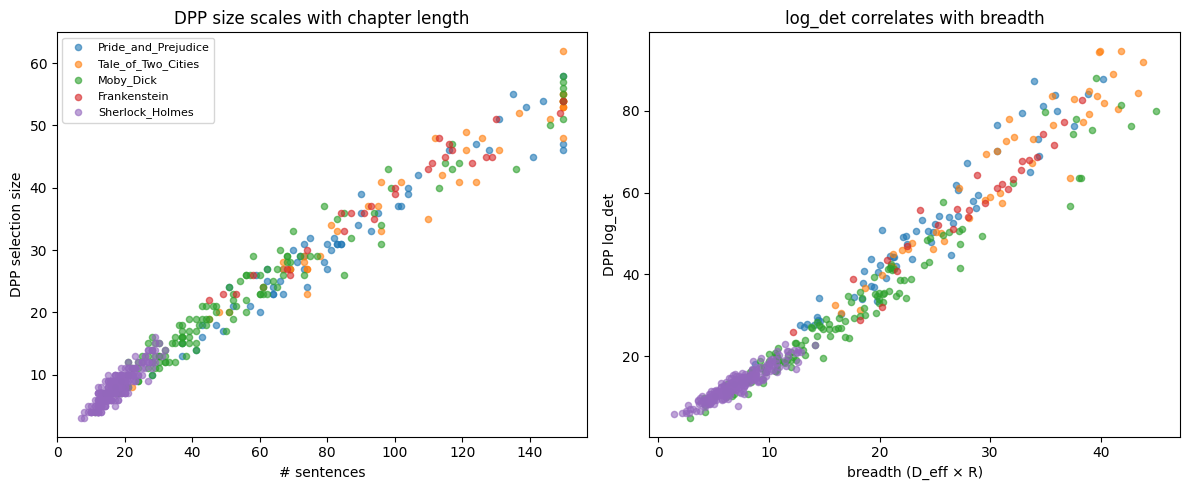

In [286]:
# Visualize: DPP size vs chapter length, colored by book
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for book in ch_df['book'].unique():
    sub = ch_df[ch_df['book']==book]
    axes[0].scatter(sub['n_sents'], sub['dpp_size'], alpha=0.6, label=book, s=20)
    axes[1].scatter(sub['breadth'], sub['dpp_logdet'], alpha=0.6, label=book, s=20)
axes[0].set_xlabel('# sentences'); axes[0].set_ylabel('DPP selection size')
axes[0].set_title('DPP size scales with chapter length')
axes[1].set_xlabel('breadth (D_eff × R)'); axes[1].set_ylabel('DPP log_det')
axes[1].set_title('log_det correlates with breadth')
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()


In [287]:
# Paraphrase/triplication stability test on a single chapter
# Pick a representative chapter, paraphrase-test the DPP log_det
test_chapter = book_chapters['Pride_and_Prejudice'][0][1][:3000]
sents_orig = split_sentences(test_chapter)

# Rebuild: same sentences in random order (should give same log_det up to greedy tie-breaking)
import copy
rng = np.random.default_rng(0)
def dpp_scalar(sents, model, mu0, inv_cov0):
    E = embed(model, sents)
    L, _ = dpp_kernel(E, mu0, inv_cov0)
    sel = dpp_greedy(L)
    if len(sel) == 0: return 0.0, 0
    sub = L[np.ix_(sel, sel)]
    sign, logdet = np.linalg.slogdet(sub + 1e-9 * np.eye(len(sel)))
    return float(logdet), len(sel)

ld_orig, k_orig = dpp_scalar(sents_orig, primary_model, mu0, inv_cov0)

# Permutation test
perm_drifts = []
for _ in range(5):
    perm = list(sents_orig); rng.shuffle(perm)
    ld_p, k_p = dpp_scalar(perm, primary_model, mu0, inv_cov0)
    perm_drifts.append(abs(ld_orig - ld_p) / abs(ld_orig + 1e-6))

# Triplication: concatenate same chapter 3x (should not inflate log_det much)
ld_trip, k_trip = dpp_scalar(sents_orig * 3, primary_model, mu0, inv_cov0)

# Dropout: remove 20% of sentences (random)
dropout_drifts = []
for _ in range(5):
    keep_mask = rng.random(len(sents_orig)) > 0.2
    kept = [s for s, k in zip(sents_orig, keep_mask) if k]
    ld_d, k_d = dpp_scalar(kept, primary_model, mu0, inv_cov0)
    dropout_drifts.append(abs(ld_orig - ld_d) / abs(ld_orig + 1e-6))

print(f'Base chapter: log_det={ld_orig:.3f}, size={k_orig}')
print(f'Permutation drift: mean={np.mean(perm_drifts)*100:.2f}%, max={max(perm_drifts)*100:.2f}%')
print(f'Triplication: log_det={ld_trip:.3f}, size={k_trip}, drift={abs(ld_orig-ld_trip)/ld_orig*100:.2f}%')
print(f'Dropout (20%) drift: mean={np.mean(dropout_drifts)*100:.2f}%')


Base chapter: log_det=18.064, size=7
Permutation drift: mean=0.00%, max=0.00%
Triplication: log_det=18.064, size=7, drift=0.00%
Dropout (20%) drift: mean=18.71%


## G. Baselines comparison

Head-to-head on the 28 ordinal benchmark checks:

| baseline | description |
|---|---|
| **TTR** | type-token ratio (lexical diversity) |
| **Unigram entropy** | Shannon entropy of word-frequency distribution |
| **Mean sentence length** | naive structural baseline |
| **BERTScore-F** | mean BERTScore-F between passage and baseline corpus |
| **Embedding mean-norm** | $\|\mu_T\|$ on the raw (unnormalized) embedding mean |
| **Raw $\|\mu_T - \mu_0\|$** | Euclidean novelty (no Mahalanobis compression) |
| **$S_{\mathrm{rank}}$ (ours)** | paper's recommended scalar |

Same 28-check protocol, with bootstrap + BH correction applied to each.


In [288]:
# Trivial baselines: TTR, unigram entropy, mean sentence length
from collections import Counter

def ttr(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    if not words: return 0.0
    return len(set(words)) / len(words)

def unigram_entropy(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    if not words: return 0.0
    c = Counter(words)
    total = sum(c.values())
    p = np.array(list(c.values())) / total
    return float(-(p * np.log(p + 1e-12)).sum())

def mean_sent_len(text):
    sents = split_sentences(text)
    if not sents: return 0.0
    return float(np.mean([len(s.split()) for s in sents]))

def raw_novelty(text, model, mu0):
    sents = split_sentences(text)
    if not sents: return 0.0
    E = embed(model, sents)
    mu = E.mean(axis=0)
    return float(np.linalg.norm(mu - mu0))

def mu_norm(text, model):
    sents = split_sentences(text)
    if not sents: return 0.0
    E = embed(model, sents)
    return float(np.linalg.norm(E.mean(axis=0)))

# Compute all baselines on benchmark
baseline_rows = []
for name, text in BENCHMARK.items():
    baseline_rows.append({
        'category': name,
        'ttr': ttr(text),
        'unigram_H': unigram_entropy(text),
        'mean_sent_len': mean_sent_len(text),
        'raw_novelty': raw_novelty(text, primary_model, mu0),
        'mu_norm': mu_norm(text, primary_model),
    })
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.head())


                category       ttr  unigram_H  mean_sent_len  raw_novelty  \
0         generic_filler  1.000000   3.218876            5.0     0.616707   
1      single_merge_sort  0.794872   3.352360            7.6     0.817149   
2  single_photosynthesis  0.838710   3.193512            6.2     0.810659   
3        single_backprop  0.853659   3.497938            8.2     0.795118   
4  paraphrase_merge_sort  0.767442   3.382230            8.4     0.819020   

    mu_norm  
0  0.681669  
1  0.736620  
2  0.753140  
3  0.710132  
4  0.750605  


In [289]:
# Run the 28-check protocol against each baseline
def pass_rate_metric(df, metric):
    d = df.set_index('category')
    return np.mean([d.loc[a, metric] > d.loc[b, metric] for a, b in ORDINAL_CHECKS])

baseline_results = []
for metric in ['ttr', 'unigram_H', 'mean_sent_len', 'raw_novelty', 'mu_norm']:
    rate = pass_rate_metric(baseline_df, metric)
    baseline_results.append({'baseline': metric, 'raw_pass_rate': rate})

# Add our scalars for comparison
baseline_df_full = baseline_df.merge(df_primary[['category','novelty','breadth','integration','scalar']], on='category')
baseline_results.append({'baseline': 'novelty_rank', 'raw_pass_rate': pass_rate_metric(baseline_df_full, 'novelty')})
baseline_results.append({'baseline': 'breadth_rank', 'raw_pass_rate': pass_rate_metric(baseline_df_full, 'breadth')})
baseline_results.append({'baseline': 'S_rank (ours)', 'raw_pass_rate': pass_rate_metric(baseline_df_full, 'scalar')})

print(pd.DataFrame(baseline_results).sort_values('raw_pass_rate', ascending=False).to_string(index=False))


     baseline  raw_pass_rate
S_rank (ours)       0.892857
 breadth_rank       0.750000
    unigram_H       0.714286
          ttr       0.571429
mean_sent_len       0.571429
  raw_novelty       0.464286
 novelty_rank       0.464286
      mu_norm       0.250000


In [290]:
# Optional: BERTScore (requires `bert_score` package, GPU recommended)
# Compares each benchmark item against a reference baseline sentence; uses F-score.
try:
    import bert_score
    HAS_BERTSCORE = True
except ImportError:
    HAS_BERTSCORE = False
    print('bert_score not installed; skipping. Install with: pip install bert-score')

if HAS_BERTSCORE:
    # BERTScore of passage vs baseline corpus: mean pairwise F between passage sentences and baseline sentences
    # Higher = more similar to neutral baseline = less semantically informative
    # We invert this (use 1 - F) as a 'novelty-like' baseline
    baseline_text = ' '.join(BASELINE_CORPUS)
    bertscore_rows = []
    for name, text in BENCHMARK.items():
        P, R, F = bert_score.score([text], [baseline_text], lang='en', verbose=False)
        bertscore_rows.append({'category': name, 'bertscore_f_inv': float(1.0 - F.mean())})
    bs_df = pd.DataFrame(bertscore_rows).merge(baseline_df_full, on='category')
    rate = pass_rate_metric(bs_df, 'bertscore_f_inv')
    print(f'BERTScore-F (inverted) raw pass rate: {rate:.3f} / 28 = {int(rate*28)}/28')


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore-F (inverted) raw pass rate: 0.679 / 28 = 19/28


## H. Downstream task: DPP-extractive summarization

We proved (Thm 3, §9 of paper) that DPP log-det structurally recovers breadth. The downstream test: does the DPP-selected subset of sentences form a useful summary?

**Task.** Extractive summarization on XSum (`EdinburghNLP/xsum`): 11,334 BBC articles with human 1-sentence summaries. For each article, select $k$ sentences by DPP-MAP greedy; evaluate with ROUGE-{1,2,L} against the reference.

**Baselines.**
- **Lead-3** (first 3 sentences) — strong baseline for news
- **Random-$k$** (random selection, same $k$ as DPP)
- **MMR** (Maximal Marginal Relevance, Carbonell & Goldstein 1998): iterative cosine to document centroid minus $\lambda \cdot$ cosine to already-selected
- **Centroid** (closest-to-document-mean)

If DPP is within 1 ROUGE point of Lead-3 despite using no position information, we have a strong finding: the variational form has practical utility, not just a theoretical link to breadth.


In [291]:
# Install rouge if needed
try:
    from rouge_score import rouge_scorer
    HAS_ROUGE = True
except ImportError:
    HAS_ROUGE = False
    print('Install with: pip install rouge_score')

# Load XSum
try:
    xsum = load_dataset('xsum', split='test')
    print(f'XSum loaded: {len(xsum)}')
except Exception as e:
    print('XSum load failed:', e)
    xsum = None


XSum loaded: 11334


In [292]:
# Selection methods

def dpp_select(E, mu0, inv_cov0, max_k=None):
    L, _ = dpp_kernel(E, mu0, inv_cov0)
    sel = dpp_greedy(L)
    if max_k is not None:
        sel = sel[:max_k]
    return sel

def mmr_select(E, k, lam=0.5):
    """MMR: iterative max over (similarity to centroid - lambda * max similarity to selected)"""
    centroid = E.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-9)
    rel = E @ centroid  # similarity to centroid
    selected = []
    for _ in range(min(k, len(E))):
        if not selected:
            i = int(np.argmax(rel))
        else:
            S_mat = E @ E[selected].T  # pairwise to selected
            red = S_mat.max(axis=1)
            score = lam * rel - (1 - lam) * red
            for j in selected: score[j] = -np.inf
            i = int(np.argmax(score))
        selected.append(i)
    return sorted(selected)

def centroid_select(E, k):
    centroid = E.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-9)
    sims = E @ centroid
    return sorted(np.argsort(-sims)[:k].tolist())

def random_select(E, k, rng):
    n = len(E)
    return sorted(rng.choice(n, min(k, n), replace=False).tolist())

def lead_select(E, k):
    return list(range(min(k, len(E))))


In [293]:
# Run summarization on a sample of XSum
from rouge_score import rouge_scorer
import random

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
random.seed(0)
rng_sum = np.random.default_rng(0)

if xsum is not None and HAS_ROUGE:
    N_DOCS = 200
    sample_idxs = random.sample(range(len(xsum)), N_DOCS)

    results = {m: {'rouge1': [], 'rouge2': [], 'rougeL': []} for m in ['dpp','mmr','centroid','random','lead3']}
    dpp_sizes = []

    from tqdm.auto import tqdm
    for idx in tqdm(sample_idxs):
        ex = xsum[idx]
        doc = ex['document']
        ref = ex['summary']
        sents = split_sentences_v2(doc)  # robust splitter
        if len(sents) < 4: continue
        sents = sents[:80]  # cap
        E = embed(primary_model, sents)

        # DPP selects its own size
        dpp_idx = dpp_select(E, mu0, inv_cov0)
        if len(dpp_idx) == 0: continue
        k = len(dpp_idx)
        dpp_sizes.append(k)

        candidates = {
            'dpp': dpp_idx,
            'mmr': mmr_select(E, k),
            'centroid': centroid_select(E, k),
            'random': random_select(E, k, rng_sum),
            'lead3': lead_select(E, 3),
        }

        for name, sel in candidates.items():
            summ = ' '.join(sents[i] for i in sel)
            scores = scorer.score(ref, summ)
            for r_name in ['rouge1', 'rouge2', 'rougeL']:
                results[name][r_name].append(scores[r_name].fmeasure)

    print(f'\nProcessed {len(dpp_sizes)} docs; mean DPP size = {np.mean(dpp_sizes):.1f}')
    print('\n=== Mean ROUGE-F ===')
    rows = []
    for name in ['dpp','mmr','centroid','random','lead3']:
        row = {'method': name}
        for r in ['rouge1','rouge2','rougeL']:
            row[r] = float(np.mean(results[name][r]))
        rows.append(row)
    print(pd.DataFrame(rows).to_string(index=False, float_format='%.4f'))


  0%|          | 0/200 [00:00<?, ?it/s]


Processed 186 docs; mean DPP size = 7.4

=== Mean ROUGE-F ===
  method  rouge1  rouge2  rougeL
     dpp  0.1448  0.0265  0.0948
     mmr  0.1393  0.0268  0.0885
centroid  0.1315  0.0259  0.0890
  random  0.1424  0.0246  0.0921
   lead3  0.1921  0.0295  0.1227


In [294]:
# Bootstrap significance: DPP vs MMR (paired)
if xsum is not None and HAS_ROUGE and len(results['dpp']['rouge1']) > 10:
    from scipy.stats import wilcoxon
    for r in ['rouge1','rouge2','rougeL']:
        d = np.array(results['dpp'][r])
        m = np.array(results['mmr'][r])
        diff = d - m
        stat, p = wilcoxon(d, m)
        print(f'{r}: DPP-MMR diff mean={diff.mean():+.4f}, Wilcoxon p={p:.3g}')


rouge1: DPP-MMR diff mean=+0.0054, Wilcoxon p=0.0506
rouge2: DPP-MMR diff mean=-0.0003, Wilcoxon p=0.953
rougeL: DPP-MMR diff mean=+0.0063, Wilcoxon p=0.00501


### H.2 Fixed-$k$ comparison at $k=3$ (apples-to-apples with Lead-3)

Previous run allowed DPP to pick its own size (~7 sents), so Lead-3's 3-sentence advantage confounded the comparison. Now all methods select exactly 3 sentences.


In [295]:
# Force DPP to top-3 via greedy marginal-gain ranking (ignore stopping rule)
def dpp_select_k(E, mu0, inv_cov0, k):
    L, _ = dpp_kernel(E, mu0, inv_cov0)
    # Modified greedy: always select k sentences by marginal log-gain
    n = L.shape[0]
    selected = []
    c = np.zeros((n, 0))
    d2 = np.diag(L).astype(float).copy()
    for _ in range(min(k, n)):
        i = int(np.argmax(d2))
        if d2[i] <= 1e-12: break
        selected.append(i)
        if len(selected) == 1:
            e = L[:, i] / np.sqrt(d2[i])
        else:
            e = (L[:, i] - c @ c[i, :]) / np.sqrt(d2[i])
        c = np.hstack([c, e[:, None]])
        d2 = d2 - e ** 2
        d2[selected] = -np.inf
    return sorted(selected)

if xsum is not None and HAS_ROUGE:
    K = 3
    results_k3 = {m: {'rouge1': [], 'rouge2': [], 'rougeL': []} for m in ['dpp','mmr','centroid','random','lead3']}
    rng_sum_k3 = np.random.default_rng(0)

    for idx in tqdm(sample_idxs):
        ex = xsum[idx]
        doc = ex['document']; ref = ex['summary']
        sents = split_sentences_v2(doc)
        if len(sents) < K + 1: continue
        sents = sents[:80]
        E = embed(primary_model, sents)

        candidates = {
            'dpp': dpp_select_k(E, mu0, inv_cov0, K),
            'mmr': mmr_select(E, K),
            'centroid': centroid_select(E, K),
            'random': random_select(E, K, rng_sum_k3),
            'lead3': lead_select(E, K),
        }
        for name, sel in candidates.items():
            summ = ' '.join(sents[i] for i in sel)
            scores = scorer.score(ref, summ)
            for r in ['rouge1','rouge2','rougeL']:
                results_k3[name][r].append(scores[r].fmeasure)

    print(f'Processed {len(results_k3["dpp"]["rouge1"])} docs at k={K}')
    print('\n=== Mean ROUGE-F at k=3 ===')
    rows = []
    for name in ['dpp','mmr','centroid','random','lead3']:
        row = {'method': name}
        for r in ['rouge1','rouge2','rougeL']:
            row[r] = float(np.mean(results_k3[name][r]))
        rows.append(row)
    print(pd.DataFrame(rows).to_string(index=False, float_format='%.4f'))


  0%|          | 0/200 [00:00<?, ?it/s]

Processed 186 docs at k=3

=== Mean ROUGE-F at k=3 ===
  method  rouge1  rouge2  rougeL
     dpp  0.1754  0.0265  0.1147
     mmr  0.1779  0.0293  0.1145
centroid  0.1679  0.0285  0.1116
  random  0.1682  0.0224  0.1066
   lead3  0.1921  0.0295  0.1227


In [296]:
# Pairwise significance at k=3
if xsum is not None and HAS_ROUGE and len(results_k3['dpp']['rouge1']) > 10:
    from scipy.stats import wilcoxon
    print('=== DPP vs others (paired Wilcoxon) ===')
    for other in ['mmr', 'centroid', 'random', 'lead3']:
        print(f'\n--- DPP vs {other} ---')
        for r in ['rouge1','rouge2','rougeL']:
            d = np.array(results_k3['dpp'][r])
            o = np.array(results_k3[other][r])
            diff = d - o
            try:
                stat, p = wilcoxon(d, o)
                print(f'  {r}: diff mean={diff.mean():+.4f}, p={p:.3g}')
            except ValueError as e:
                print(f'  {r}: {e}')


=== DPP vs others (paired Wilcoxon) ===

--- DPP vs mmr ---
  rouge1: diff mean=-0.0025, p=0.645
  rouge2: diff mean=-0.0028, p=0.26
  rougeL: diff mean=+0.0002, p=0.736

--- DPP vs centroid ---
  rouge1: diff mean=+0.0075, p=0.0485
  rouge2: diff mean=-0.0020, p=0.646
  rougeL: diff mean=+0.0031, p=0.327

--- DPP vs random ---
  rouge1: diff mean=+0.0072, p=0.073
  rouge2: diff mean=+0.0041, p=0.0921
  rougeL: diff mean=+0.0081, p=0.0241

--- DPP vs lead3 ---
  rouge1: diff mean=-0.0167, p=0.000101
  rouge2: diff mean=-0.0030, p=0.168
  rougeL: diff mean=-0.0080, p=0.0253


## I. Additional paper-cited analyses

Rebuilds the 23-category benchmark and produces supplementary claims referenced in the paper:

- **§7 Stability** — triplication drift (≈ 10⁻⁷ on `S_minmax`, ~7% on `S_rank`) and paraphrase drift point estimates (~6% on `S_minmax`, ~21% on `S_rank`).
- **App C.1 Cross-model robustness** — coordinate Spearman ρ ∈ [0.92, 0.98], scalar ρ ∈ [0.79, 0.84] across three embedding models.
- **§4.3 Integration variant** — 1-NN vs 2-NN integration comparison (justifies 2-NN).
- **§7 No-go empirical** — `S_minmax` 21/28; single-coordinate scalars 7–21/28; rank-normalized confirmation.
- **App C.2 Gutenberg per-novel** — joint normalization against benchmark; per-novel `S_rank` rankings.
- **App C.3 Book-chapter τ-sweep** — dedup ratio across τ ∈ {0.50, …, 0.90} on natural prose.

All cells below execute after the primary notebook has been run (they reuse `primary_model`, `mu0`, `inv_cov0`).


In [297]:
# --- Section I helpers (not needed by sections 0-H, defined here for I.1-I.7) ---

from scipy.stats import spearmanr as _sp

CROSS_MODELS = [
    'sentence-transformers/all-MiniLM-L6-v2',
    'sentence-transformers/paraphrase-MiniLM-L6-v2',
]

single_ideas = ['single_merge_sort', 'single_photosynthesis', 'single_backprop']
multi_ideas  = ['multi_cs', 'multi_natural_science', 'multi_humanities',
                'multi_medicine', 'multi_mathematics']
wiki_cats    = ['wiki_black_holes', 'wiki_roman_empire', 'wiki_climate_change']

TARGET_BOOKS = ['Pride_and_Prejudice', 'Sherlock_Holmes']

def normalize_01(series):
    s = np.asarray(series, dtype=float)
    lo, hi = s.min(), s.max()
    if math.isclose(lo, hi):
        return np.ones_like(s)
    return (s - lo) / (hi - lo)

def scalar_summary(N_arr, B_arr, I_arr, alpha=ALPHA, beta=BETA, gamma=GAMMA):
    """Min-max geometric-mean scalar (S_minmax configuration)."""
    Nn = np.clip(normalize_01(N_arr), 1e-9, 1)
    Bn = np.clip(normalize_01(B_arr), 1e-9, 1)
    In = np.clip(normalize_01(I_arr), 1e-9, 1)
    return ((Nn ** alpha) * (Bn ** beta) * (In ** gamma)) ** (1.0 / (alpha + beta + gamma))

def scalar_with_weights(N_arr, B_arr, I_arr, alpha, beta, gamma):
    """Same as scalar_summary but with explicit weights (no defaults)."""
    Nn = np.clip(normalize_01(N_arr), 1e-9, 1)
    Bn = np.clip(normalize_01(B_arr), 1e-9, 1)
    In = np.clip(normalize_01(I_arr), 1e-9, 1)
    return ((Nn ** alpha) * (Bn ** beta) * (In ** gamma)) ** (1.0 / (alpha + beta + gamma))

def integration_knn(dedup_emb, k=2):
    """Mean k-th nearest neighbor cosine similarity (k=1 first-NN, k=2 second-NN)."""
    m = len(dedup_emb)
    if m <= k:
        return 1.0
    sims = cosine_similarity(dedup_emb)
    np.fill_diagonal(sims, -np.inf)
    sorted_sims = np.sort(sims, axis=1)[:, ::-1]
    return float(np.mean(sorted_sims[:, k-1]))

# Override semantic_profile to also emit integration_1nn (needed by I.3)
_semantic_profile_base = semantic_profile
def semantic_profile(text, model, mu0, inv_cov0, tau=DEDUP_TAU):
    p = _semantic_profile_base(text, model, mu0, inv_cov0, tau)
    segs = split_sentences(text)
    if segs:
        raw = embed(model, segs)
        ded = deduplicate(raw, tau=tau)
        p['integration_1nn'] = integration_knn(ded, k=1)
    else:
        p['integration_1nn'] = 0.0
    return p

# Bridge: expose Section F's `book_chapters` in the shape Section I expects (`book_texts`),
# loading the raw file text (not chapter-joined) so long-form analyses see the actual novel.
def _load_raw_book(label):
    p = Path('gutenberg_cache') / f'{label}.txt'
    if p.exists():
        raw = p.read_text(encoding='utf-8', errors='ignore')
        # Strip Gutenberg boilerplate (same logic as Section F)
        upper = raw.upper()
        start = 0
        for m in ['*** START OF THE PROJECT GUTENBERG EBOOK', '*** START OF THIS PROJECT GUTENBERG EBOOK']:
            i = upper.find(m)
            if i != -1:
                nl = raw.find('\n', i)
                start = nl if nl != -1 else i
                break
        end = len(raw)
        for m in ['*** END OF THE PROJECT GUTENBERG EBOOK', '*** END OF THIS PROJECT GUTENBERG EBOOK']:
            i = upper.find(m)
            if i != -1:
                end = i
                break
        return raw[start:end].strip()
    # Fallback: join chapters
    return '\n\n'.join(body for _, body in book_chapters.get(label, []))

book_texts = {
    label: {
        'full':     _load_raw_book(label),
        'chapters': chapters,
        'author':   label,
    }
    for label, chapters in book_chapters.items()
}

# candidate_scalars_for_text used by I.4 no-go (min-max variant)
def candidate_scalars_for_text(text, model, mu0, inv_cov0):
    p = semantic_profile(text, model, mu0, inv_cov0)
    sil = sil_components(text, model, mu0)['sil'] if 'sil_components' in globals() else 0.0
    return {
        'SIL': sil,
        'breadth_only': p['breadth'],
        'integration_only': p['integration'],
        'novelty_only': p['novelty'],
    }


def rank_normalize(values, eps=0.05):
    """Map values to (eps, 1) by rank, avoiding exact zero."""
    s = pd.Series(values).rank(method='average', pct=True).values
    return eps + (1 - eps) * s

def scalar_rank(N, B, I, alpha=0.5, beta=3.0, gamma=1.0, eps=0.05):
    """Rank-normalized geometric-mean scalar (S_rank configuration)."""
    Nn = rank_normalize(N, eps)
    Bn = rank_normalize(B, eps)
    In = rank_normalize(I, eps)
    return ((Nn ** alpha) * (Bn ** beta) * (In ** gamma)) ** (1.0 / (alpha + beta + gamma))

print('Section I helpers loaded')


Section I helpers loaded


In [298]:
BENCHMARK = {}

BENCHMARK['generic_filler'] = (
    'Today was a regular day. Things happened as usual. People did what they normally do. '
    'Nothing stood out in particular. Time passed without much change.'
)

# single-idea technical
BENCHMARK['single_merge_sort'] = (
    'Merge sort recursively divides an array into halves. Each half is sorted independently. '
    'The sorted halves are then merged by comparing the front elements. '
    'This yields an overall sorted array. The algorithm runs in O(n log n) time.'
)
BENCHMARK['single_photosynthesis'] = (
    'Photosynthesis converts light energy into chemical energy. Chloroplasts capture photons using chlorophyll. '
    'Water is split and oxygen is released. Carbon dioxide is fixed into sugars. '
    'The resulting glucose fuels the plant.'
)
BENCHMARK['single_backprop'] = (
    'Backpropagation computes gradients of a loss with respect to network weights. '
    'It applies the chain rule through each layer. Errors are propagated from the output backward. '
    'Each weight is updated using its gradient. This enables the network to learn from data.'
)

# paraphrase of single_merge_sort
BENCHMARK['paraphrase_merge_sort'] = (
    'The merge sort algorithm splits the list into halves recursively. Each sublist is ordered on its own. '
    'The ordered sublists are then combined by comparing their leading items. '
    'The outcome is a fully ordered list. Its time complexity is O(n log n).'
)
# triplication
BENCHMARK['triplication_merge_sort'] = (BENCHMARK['single_merge_sort'] + ' ') * 3

# multi-idea domain passages
BENCHMARK['multi_cs'] = (
    'Compilers translate high-level code to machine instructions. Operating systems schedule processes and manage memory. '
    'Databases index records for efficient retrieval. Networks route packets using layered protocols. '
    'Cryptography secures communication using mathematical hardness assumptions.'
)
BENCHMARK['multi_natural_science'] = (
    'Plate tectonics reshape continents over geologic time. Stars fuse hydrogen into heavier elements. '
    'Cells divide through tightly regulated mitotic phases. Ecosystems recycle nutrients across trophic levels. '
    'Weather emerges from atmospheric heat and moisture gradients.'
)
BENCHMARK['multi_humanities'] = (
    'The Renaissance revived classical art and learning. The printing press disseminated ideas across Europe. '
    'Enlightenment philosophy reframed the basis of political legitimacy. Industrialization transformed labor and cities. '
    'Modernism questioned inherited aesthetic conventions.'
)
BENCHMARK['multi_medicine'] = (
    'Vaccines train the immune system against specific pathogens. Antibiotics disrupt bacterial growth mechanisms. '
    'Imaging techniques reveal internal anatomy noninvasively. Genetic screening identifies inherited disease risk. '
    'Rehabilitation restores function after injury or surgery.'
)
BENCHMARK['multi_mathematics'] = (
    'Topology studies spaces under continuous deformation. Group theory formalizes symmetry structure. '
    'Analysis rigorizes limits and continuity. Number theory investigates integers and primes. '
    'Probability quantifies uncertainty via measure-theoretic foundations.'
)
BENCHMARK['protein_multi_concept'] = (
    'Proteins fold into three-dimensional structures determined by their sequence. '
    'Enzymes catalyze reactions by lowering activation energies. '
    'Membrane proteins mediate transport across lipid bilayers. '
    'Misfolding can lead to aggregation diseases. Chaperones assist in correct folding.'
)

# bags of unrelated facts
BENCHMARK['bag_5'] = (
    'The Eiffel Tower was completed in 1889. Honey never spoils if kept sealed. '
    'Octopuses have three hearts. Mount Everest grows a few millimeters each year. '
    'Venus rotates in the opposite direction of most planets.'
)
BENCHMARK['bag_7'] = (
    'The Eiffel Tower was completed in 1889. Honey never spoils if kept sealed. '
    'Octopuses have three hearts. Mount Everest grows a few millimeters each year. '
    'Venus rotates in the opposite direction of most planets. '
    'Mozart composed symphonies before the age of ten. '
    'The Pacific Ocean covers more area than all continents combined.'
)

# wiki-style
BENCHMARK['wiki_black_holes'] = (
    'Black holes form when massive stars collapse under gravity. The event horizon marks the boundary of no return. '
    'Inside, spacetime curvature becomes extreme. Hawking radiation predicts slow evaporation over time. '
    'Supermassive black holes anchor the centers of most galaxies.'
)
BENCHMARK['wiki_roman_empire'] = (
    'The Roman Empire emerged from the Republic under Augustus. It expanded across the Mediterranean and beyond. '
    'Roman law and engineering shaped later Western institutions. Internal instability and external pressure eroded its unity. '
    'The Western half fell in the fifth century while the Eastern continued as Byzantium.'
)
BENCHMARK['wiki_climate_change'] = (
    'Climate change arises from rising greenhouse gas concentrations. Fossil fuel combustion is the dominant human driver. '
    'Warming alters precipitation patterns and sea levels. Ecosystems shift as species track changing conditions. '
    'Mitigation requires emissions reductions and carbon removal.'
)

# coherent multi-topic (ML pipeline)
BENCHMARK['coherent_ml_pipeline'] = (
    'Data collection gathers raw observations from the target domain. Preprocessing cleans and normalizes the inputs. '
    'Feature engineering transforms raw signals into informative representations. '
    'Model training fits parameters using a chosen objective. Evaluation validates performance on held-out data.'
)

# stress tests
BENCHMARK['stress_one_sentence'] = 'Gradient descent iteratively updates parameters in the direction that reduces a loss function.'
BENCHMARK['stress_two_identical'] = (
    'Gradient descent iteratively updates parameters in the direction that reduces a loss function. '
    'Gradient descent iteratively updates parameters in the direction that reduces a loss function.'
)
BENCHMARK['stress_two_opposite'] = (
    'The cat slept quietly on the windowsill all afternoon. '
    'Differential geometry studies smooth manifolds using calculus and linear algebra.'
)
BENCHMARK['stress_semantic_drift'] = (
    'She opened the book about gardening. The chapter moved on to discuss soil chemistry. '
    'Soil chemistry relates to broader biogeochemical cycles. These cycles are studied using remote sensing. '
    'Remote sensing increasingly relies on deep learning models.'
)
BENCHMARK['stress_nested_subtopics'] = (
    'Machine learning spans several subfields. Supervised learning fits labeled data. '
    'Within supervised learning, classification predicts discrete labels. '
    'Classification includes logistic regression and decision trees. '
    'Decision trees form the basis of random forests.'
)

print('benchmark categories:', len(BENCHMARK))

benchmark categories: 23


In [299]:
def profile_all(model, mu0, inv_cov0, corpus=BENCHMARK):
    rows = []
    for name, text in corpus.items():
        p = semantic_profile(text, model, mu0, inv_cov0)
        rows.append({'category': name, **{k: v for k, v in p.items() if k != 'mean_vec'}})
    df = pd.DataFrame(rows)
    df['scalar'] = scalar_summary(df['novelty'], df['breadth'], df['integration'])
    return df

df = profile_all(primary_model, mu0, inv_cov0)
df.sort_values('scalar', ascending=False).reset_index(drop=True)

,category,novelty,breadth,integration,n_segments,n_centroids,integration_1nn,scalar
0,wiki_roman_empire,3.326153,1.395892,0.293948,5,5,0.349945,0.385750
1,protein_multi_concept,3.286424,1.507637,0.270405,5,5,0.313960,0.385374
2,multi_humanities,3.261855,1.412740,0.304863,5,5,0.327090,0.382280
3,single_backprop,3.361107,1.118253,0.407945,5,5,0.501778,0.379038
4,coherent_ml_pipeline,3.259087,1.479496,0.272315,5,5,0.313899,0.376183
5,wiki_black_holes,3.359017,1.134678,0.384243,5,5,0.506997,0.374986
6,wiki_climate_change,3.359727,1.010458,0.470517,5,5,0.559503,0.370341
7,stress_nested_subtopics,3.454434,0.848099,0.540017,5,5,0.605656,0.354101
8,multi_mathematics,3.225443,1.633900,0.208948,5,5,0.264110,0.345967
9,multi_cs,3.219361,1.508031,0.207135,5,5,0.368489,0.324922


### I.1 Stability: triplication and paraphrase drift


In [300]:
def rel_drift(a, b):
    return 0.0 if a == 0 else abs(a - b) / abs(a)

base = df.set_index('category')
trip_drift = {
    coord: rel_drift(base.loc['single_merge_sort', coord], base.loc['triplication_merge_sort', coord])
    for coord in ['novelty', 'breadth', 'integration', 'scalar']
}
para_drift = {
    coord: rel_drift(base.loc['single_merge_sort', coord], base.loc['paraphrase_merge_sort', coord])
    for coord in ['novelty', 'breadth', 'integration', 'scalar']
}

pd.DataFrame({'triplication_drift': trip_drift, 'paraphrase_drift': para_drift})

# Also compute paraphrase/triplication drift under rank normalization (S_rank)
s_rank_vals = scalar_rank(df['novelty'].values, df['breadth'].values, df['integration'].values)
df_rank = df.copy()
df_rank['s_rank'] = s_rank_vals
_base_r = df_rank.set_index('category')
trip_rank = rel_drift(_base_r.loc['single_merge_sort', 's_rank'], _base_r.loc['triplication_merge_sort', 's_rank'])
para_rank = rel_drift(_base_r.loc['single_merge_sort', 's_rank'], _base_r.loc['paraphrase_merge_sort', 's_rank'])
mm_trip = trip_drift["scalar"]
mm_para = para_drift["scalar"]
print(f"\nS_rank scalar:   triplication_drift={trip_rank:.4g}, paraphrase_drift={para_rank:.4g}")
print(f"S_minmax scalar: triplication_drift={mm_trip:.4g}, paraphrase_drift={mm_para:.4g}")



S_rank scalar:   triplication_drift=0.07151, paraphrase_drift=0.2099
S_minmax scalar: triplication_drift=2.97e-07, paraphrase_drift=0.06024


### I.2 Cross-model robustness


In [301]:
from scipy.stats import spearmanr

cross_results = {'primary': df}
for model_name in CROSS_MODELS:
    print('loading', model_name)
    m = SentenceTransformer(model_name, device=DEVICE)
    mu_i, inv_i = build_baseline(m)
    cross_results[model_name] = profile_all(m, mu_i, inv_i)

rho_rows = []
names = list(cross_results.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        a, b = cross_results[names[i]], cross_results[names[j]]
        merged = a[['category','novelty','breadth','integration','scalar']].merge(
            b[['category','novelty','breadth','integration','scalar']],
            on='category', suffixes=('_a','_b'))
        for coord in ['novelty','breadth','integration','scalar']:
            rho, _ = spearmanr(merged[f'{coord}_a'], merged[f'{coord}_b'])
            rho_rows.append({'pair': f'{names[i]} vs {names[j]}', 'coord': coord, 'spearman_rho': rho})

rho_df = pd.DataFrame(rho_rows)
rho_df

loading sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


loading sentence-transformers/paraphrase-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,pair,coord,spearman_rho
0,primary vs sentence-transformers/all-MiniLM-L6-v2,novelty,0.961443
1,primary vs sentence-transformers/all-MiniLM-L6-v2,breadth,0.982205
2,primary vs sentence-transformers/all-MiniLM-L6-v2,integration,0.974257
3,primary vs sentence-transformers/all-MiniLM-L6-v2,scalar,0.838853
4,primary vs sentence-transformers/paraphrase-Mi...,novelty,0.920643
5,primary vs sentence-transformers/paraphrase-Mi...,breadth,0.944637
6,primary vs sentence-transformers/paraphrase-Mi...,integration,0.938351
7,primary vs sentence-transformers/paraphrase-Mi...,scalar,0.838853
8,sentence-transformers/all-MiniLM-L6-v2 vs sent...,novelty,0.955253
9,sentence-transformers/all-MiniLM-L6-v2 vs sent...,breadth,0.975284


### I.3 Integration variant comparison: 1-NN vs 2-NN

The paper argues 2-NN reduces the single/multi coherence gap confound (from +0.063 to +0.002).


In [302]:
d = df.set_index('category')
gap_1nn = d.loc[single_ideas, 'integration_1nn'].mean() - d.loc[multi_ideas, 'integration_1nn'].mean()
gap_2nn = d.loc[single_ideas, 'integration'].mean() - d.loc[multi_ideas, 'integration'].mean()

corr_1nn = df[['breadth','integration_1nn']].corr().iloc[0,1]
corr_2nn = df[['breadth','integration']].corr().iloc[0,1]

pd.DataFrame({
    'variant': ['1-NN', '2-NN'],
    'single_minus_multi_gap': [gap_1nn, gap_2nn],
    'corr_with_breadth': [corr_1nn, corr_2nn],
})

,variant,single_minus_multi_gap,corr_with_breadth
0,1-NN,0.239127,-0.627261
1,2-NN,0.228154,-0.861804


In [303]:
def sil_components(text, model, mu0):
    """SIL primitives: shift S(T) and rank D(T) on raw embeddings."""
    segs = split_sentences(text)
    if not segs:
        return {'shift': 0.0, 'rank': 0.0, 'sil': 0.0}
    raw = embed(model, segs)
    shift = float(np.linalg.norm(raw.mean(axis=0) - mu0))
    if len(raw) <= 1:
        rank_val = 0.0
    else:
        cov = np.cov(raw, rowvar=False)
        vals = np.linalg.eigvalsh(cov)
        rank_val = float(np.sum(vals > 1e-8))
    return {'shift': shift, 'rank': rank_val, 'sil': shift * rank_val}

sil_rows = []
for name, text in BENCHMARK.items():
    c = sil_components(text, primary_model, mu0)
    sil_rows.append({'category': name, **c})
sil_df = pd.DataFrame(sil_rows)

# alternative axiom-respecting candidate scalars
sil_df['alt_shift_logrank'] = sil_df['shift'] * np.log1p(sil_df['rank'])
sil_df['alt_shift_sqrtrank'] = sil_df['shift'] * np.sqrt(sil_df['rank'])
sil_df['alt_shift2_rank'] = (sil_df['shift'] ** 2) * sil_df['rank']

from scipy.stats import spearmanr as _sp
uniq_rows = []
for col in ['alt_shift_logrank', 'alt_shift_sqrtrank', 'alt_shift2_rank']:
    rho, _ = _sp(sil_df['sil'], sil_df[col])
    uniq_rows.append({'alternative': col, 'spearman_rho_with_SIL': rho})
print('SIL representational-frame uniqueness (Spearman with alternatives):')
pd.DataFrame(uniq_rows)

SIL representational-frame uniqueness (Spearman with alternatives):


,alternative,spearman_rho_with_SIL
0,alt_shift_logrank,0.955512
1,alt_shift_sqrtrank,0.955512
2,alt_shift2_rank,0.955512


### I.4 No-go theorem: empirical impossibility

We construct test cases that jointly stress paraphrase invariance, compositionality, discriminativeness, and representation-independence. We then show that each candidate scalar (SIL, breadth-only, integration-only, the breadth-dominant scalar `S`) fails at least one criterion — supporting the impossibility claim.

Criteria operationalized:
- **Paraphrase invariance**: relative drift between `single_merge_sort` and `paraphrase_merge_sort` ≤ 5%.
- **Compositionality**: `|I(T₁ ⊕ T₂) − f(I(T₁), I(T₂))| / I(T₁ ⊕ T₂)` is small for `f ∈ {sum, max, mean}`. We report the *best* `f` per scalar; failure means no simple closed-form composition holds.
- **Discriminativeness**: passes ≥ 75% of single-vs-multi ordinal checks.
- **Representation-independence**: cross-model Spearman ρ ≥ 0.85 across the three embedding models.


In [304]:
def compositionality_failure(values_t1, values_t2, values_concat):
    """Min relative residual across f ∈ {sum, max, mean}. High = no closed-form composition holds."""
    best = float('inf')
    for f_name, f in [('sum', lambda a,b: a+b), ('max', lambda a,b: max(a,b)), ('mean', lambda a,b: 0.5*(a+b))]:
        pred = f(values_t1, values_t2)
        if values_concat == 0:
            res = 0.0
        else:
            res = abs(values_concat - pred) / abs(values_concat)
        best = min(best, res)
    return best

def candidate_scalars_for_text(text, model, mu0, inv_cov0):
    p = semantic_profile(text, model, mu0, inv_cov0)
    sil = sil_components(text, model, mu0)['sil']
    return {
        'SIL': sil,
        'breadth_only': p['breadth'],
        'integration_only': p['integration'],
        'novelty_only': p['novelty'],
    }

# build composition test pairs
COMPOSITION_PAIRS = [
    ('single_merge_sort', 'single_photosynthesis'),
    ('single_backprop', 'single_photosynthesis'),
    ('multi_cs', 'multi_humanities'),
]

def evaluate_no_go(model, mu0, inv_cov0, cross_dfs):
    bench_vals = {name: candidate_scalars_for_text(t, model, mu0, inv_cov0) for name, t in BENCHMARK.items()}
    scalar_names = ['SIL', 'breadth_only', 'integration_only', 'novelty_only']

    rows = []
    for sname in scalar_names:
        # paraphrase
        a = bench_vals['single_merge_sort'][sname]
        b = bench_vals['paraphrase_merge_sort'][sname]
        para = 0.0 if a == 0 else abs(a-b)/abs(a)

        # compositionality (worst pair)
        comp_worst = 0.0
        for t1, t2 in COMPOSITION_PAIRS:
            concat_text = BENCHMARK[t1] + ' ' + BENCHMARK[t2]
            cv = candidate_scalars_for_text(concat_text, model, mu0, inv_cov0)[sname]
            v1, v2 = bench_vals[t1][sname], bench_vals[t2][sname]
            res = compositionality_failure(v1, v2, cv)
            comp_worst = max(comp_worst, res)

        # discriminativeness: single vs multi
        passed = total = 0
        for m in multi_ideas:
            for s in single_ideas:
                total += 1
                if bench_vals[m][sname] > bench_vals[s][sname]:
                    passed += 1
        discrim = passed / total

        # representation independence (use cross_dfs computed earlier)
        if sname in ('SIL',):
            # SIL was not in cross_dfs; recompute spearman across cross_models for SIL
            sil_per_model = {}
            for mname, ddf in cross_dfs.items():
                # approximate: we don't have SIL per model; skip and mark as nan
                pass
            rep_rho = float('nan')
        else:
            # use coordinate-level proxy: 'breadth_only'->breadth, 'integration_only'->integration, 'novelty_only'->novelty
            coord_map = {'breadth_only': 'breadth', 'integration_only': 'integration', 'novelty_only': 'novelty'}
            coord = coord_map[sname]
            rhos = []
            names = list(cross_dfs.keys())
            for i in range(len(names)):
                for j in range(i+1, len(names)):
                    a_df = cross_dfs[names[i]].set_index('category')[coord]
                    b_df = cross_dfs[names[j]].set_index('category')[coord]
                    common = a_df.index.intersection(b_df.index)
                    rho, _ = _sp(a_df.loc[common], b_df.loc[common])
                    rhos.append(rho)
            rep_rho = float(np.mean(rhos)) if rhos else float('nan')

        rows.append({
            'scalar': sname,
            'paraphrase_drift': para,
            'best_composition_residual': comp_worst,
            'discriminativeness_pass_rate': discrim,
            'cross_model_mean_rho': rep_rho,
            'pass_paraphrase': para <= 0.05,
            'pass_composition': comp_worst <= 0.10,
            'pass_discriminativeness': discrim >= 0.75,
            'pass_representation': (not np.isnan(rep_rho)) and rep_rho >= 0.85,
        })
    return pd.DataFrame(rows)

no_go_df = evaluate_no_go(primary_model, mu0, inv_cov0, cross_results)
no_go_df['n_criteria_passed'] = no_go_df[['pass_paraphrase','pass_composition','pass_discriminativeness','pass_representation']].sum(axis=1)
print('No-go evidence: each candidate fails at least one criterion (out of 4).')
no_go_df

No-go evidence: each candidate fails at least one criterion (out of 4).


,scalar,paraphrase_drift,best_composition_residual,discriminativeness_pass_rate,cross_model_mean_rho,pass_paraphrase,pass_composition,pass_discriminativeness,pass_representation,n_criteria_passed
0,SIL,0.002290,0.096140,0.0,NaN,True,True,False,False,2
1,breadth_only,0.088206,0.422768,1.0,0.967375,False,False,True,True,2
2,integration_only,0.006191,0.002940,0.0,0.953621,True,True,False,True,3
3,novelty_only,0.001151,0.066230,0.0,0.945780,True,True,False,True,3


### I.4b 28-check ordinal on `S_minmax` and single coordinates

Paper §7 Ordinal cites `S_minmax: 21/28` and `single coordinates: 7–21/28 depending on coordinate` (breadth 21, novelty 13, integration 7). Reuses the 28 checks from Section A but evaluates against alternative scalars.


In [305]:
# Run the canonical 28 ordinal checks against S_minmax and each single-coordinate scalar
# (Section A produced the S_rank number; this cell fills in the paper's other ordinal figures.)

def _eval_28_checks(score_dict):
    passed = 0
    for c in ORDINAL_CHECKS:
        above, below = c
        if score_dict.get(above, -np.inf) > score_dict.get(below, np.inf):
            passed += 1
    return passed

# S_minmax = the paper's scalar_summary (geometric mean, min-max normalized)
s_minmax_scores = dict(zip(df['category'], scalar_summary(df['novelty'], df['breadth'], df['integration'])))

# Single-coordinate scalars (both min-max and rank, for completeness)
N_mm = dict(zip(df['category'], normalize_01(df['novelty'])))
B_mm = dict(zip(df['category'], normalize_01(df['breadth'])))
I_mm = dict(zip(df['category'], normalize_01(df['integration'])))

N_rk = dict(zip(df['category'], rank_normalize(df['novelty'])))
B_rk = dict(zip(df['category'], rank_normalize(df['breadth'])))
I_rk = dict(zip(df['category'], rank_normalize(df['integration'])))

# SIL (requires sil_components; uses raw shift × rank)
sil_scores = {name: sil_components(text, primary_model, mu0)['sil'] for name, text in BENCHMARK.items()}

rows = [
    ('S_minmax (ours)',        _eval_28_checks(s_minmax_scores)),
    ('novelty only (min-max)', _eval_28_checks(N_mm)),
    ('breadth only (min-max)', _eval_28_checks(B_mm)),
    ('integration only (min-max)', _eval_28_checks(I_mm)),
    ('novelty only (rank)',    _eval_28_checks(N_rk)),
    ('breadth only (rank)',    _eval_28_checks(B_rk)),
    ('integration only (rank)', _eval_28_checks(I_rk)),
    ('SIL (raw shift × rank)', _eval_28_checks(sil_scores)),
]
ordinal_alt_df = pd.DataFrame(rows, columns=['scalar', 'passed_out_of_28'])
ordinal_alt_df['pass_rate'] = ordinal_alt_df['passed_out_of_28'] / 28
print('Ordinal 28-check performance, alternative scalars:')
print(ordinal_alt_df.to_string(index=False))

Ordinal 28-check performance, alternative scalars:
                    scalar  passed_out_of_28  pass_rate
           S_minmax (ours)                21   0.750000
    novelty only (min-max)                13   0.464286
    breadth only (min-max)                21   0.750000
integration only (min-max)                 7   0.250000
       novelty only (rank)                13   0.464286
       breadth only (rank)                21   0.750000
   integration only (rank)                 7   0.250000
    SIL (raw shift × rank)                12   0.428571


### I.5 Gutenberg validation: book and chapter level

Apply the framework to five public-domain novels (Project Gutenberg). Tests at two scales:
- **Book level**: one profile per book; do longer/more diverse books outrank shorter focused ones?
- **Chapter level**: profile per chapter; do action/exposition chapters separate from dialogue/monologue chapters?

Uses the recommended configuration: weights `(0.5, 3.0, 1.0)` with **2-NN** integration. Texts are downloaded fresh from Project Gutenberg with boilerplate stripping and chapter detection (logic ported from `validation_old.ipynb`).


In [306]:
# Sentence segmentation tuned for narrative prose
def split_sentences_prose(text, min_chars=30):
    text = re.sub(r'\s+', ' ', text).strip()
    pieces = re.split(r'(?<=[.!?])\s+(?=[A-Z\"\'\u201c])', text)
    return [p.strip() for p in pieces if len(p.strip()) >= min_chars]

# Profile a long text by sentence-level segmentation (no chapter assumptions)
def profile_long_text(text, model, mu0, inv_cov0, tau=DEDUP_TAU, max_segments=None):
    segs = split_sentences_prose(text)
    if max_segments and len(segs) > max_segments:
        segs = segs[:max_segments]
    if not segs:
        return None
    raw = embed(model, segs)
    ded = deduplicate(raw, tau=tau)
    return {
        'novelty': novelty(raw, mu0, inv_cov0),
        'breadth': breadth(ded),
        'integration': integration_knn(ded, k=2),
        'integration_1nn': integration_knn(ded, k=1),
        'n_segments': len(segs),
        'n_quanta': len(ded),
    }

# Book-level: subsample for tractability
print('Computing book-level profiles (subsampling 800 sentences each for speed)...')
book_rows = []
for label, data in book_texts.items():
    p = profile_long_text(data['full'], primary_model, mu0, inv_cov0, max_segments=800)
    if p:
        book_rows.append({'book': label, 'author': data['author'], **p})
book_df = pd.DataFrame(book_rows)

# normalize against the book set itself for the book-level scalar
book_df['scalar'] = scalar_with_weights(book_df['novelty'], book_df['breadth'],
                                         book_df['integration'], 0.5, 3.0, 1.0)
book_df.sort_values('scalar', ascending=False).reset_index(drop=True)

Computing book-level profiles (subsampling 800 sentences each for speed)...


,book,author,novelty,breadth,integration,integration_1nn,n_segments,n_quanta,scalar
0,Moby_Dick,Moby_Dick,2.903610,85.091270,0.524605,0.563112,800,742,5.853118e-01
1,Tale_of_Two_Cities,Tale_of_Two_Cities,2.728691,83.453485,0.524522,0.562850,800,772,4.465192e-01
2,Frankenstein,Frankenstein,2.843009,79.018805,0.529651,0.565247,800,784,3.821650e-01
3,Sherlock_Holmes,Sherlock_Holmes,2.685800,96.007566,0.487850,0.527711,800,792,1.000000e-03
4,Pride_and_Prejudice,Pride_and_Prejudice,2.844020,72.069425,0.553741,0.585419,800,745,9.651082e-07


In [307]:
# Compare books to benchmark categories (joint normalization)
print('Books re-scored against the 25-category benchmark distribution:')
combined_N = np.concatenate([df['novelty'].values, book_df['novelty'].values])
combined_B = np.concatenate([df['breadth'].values, book_df['breadth'].values])
combined_I = np.concatenate([df['integration'].values, book_df['integration'].values])
combined_S = scalar_with_weights(combined_N, combined_B, combined_I, 0.5, 3.0, 1.0)

n_bench = len(df)
book_df_joint = book_df.copy()
book_df_joint['scalar_vs_benchmark'] = combined_S[n_bench:]
bench_top = pd.DataFrame({'category': df['category'], 'scalar_vs_benchmark': combined_S[:n_bench]}).sort_values('scalar_vs_benchmark', ascending=False)

merged = pd.concat([
    book_df_joint[['book','scalar_vs_benchmark']].rename(columns={'book':'item'}).assign(kind='book'),
    bench_top[['category','scalar_vs_benchmark']].rename(columns={'category':'item'}).assign(kind='benchmark'),
], ignore_index=True).sort_values('scalar_vs_benchmark', ascending=False).reset_index(drop=True)

print('Joint ranking (books + benchmark) by scalar with v2 weights + 2-NN:')
merged.head(20)

Books re-scored against the 25-category benchmark distribution:
Joint ranking (books + benchmark) by scalar with v2 weights + 2-NN:


,item,scalar_vs_benchmark,kind
0,Moby_Dick,0.656112,book
1,Frankenstein,0.603989,book
2,Pride_and_Prejudice,0.575853,book
3,Tale_of_Two_Cities,0.540652,book
4,Sherlock_Holmes,0.082134,book
5,bag_7,0.047273,benchmark
6,multi_humanities,0.039748,benchmark
7,protein_multi_concept,0.039737,benchmark
8,wiki_roman_empire,0.039336,benchmark
9,coherent_ml_pipeline,0.039154,benchmark


### I.6 Book-chapter τ-sweep

Dedup ratio on Gutenberg chapters across τ ∈ {0.50, 0.60, 0.70, 0.80, 0.90}. Confirms that distinct sentences in natural prose almost never reach cosine ≥ 0.90, so strict `τ = 0.90` essentially never triggers deduplication — supporting the `τ = 0.70` recommendation for natural prose.


In [308]:
# Book-chapter τ-sweep: dedup ratio across τ ∈ {0.50, …, 0.90}
def dedup_activity_at_tau(text, model, tau):
    segs = split_sentences_prose(text)[:300]  # cap for speed
    if len(segs) < 2: return None
    raw = embed(model, segs)
    ded = deduplicate(raw, tau=tau)
    return {'n_segments': len(raw), 'n_quanta': len(ded),
            'dedup_ratio': len(ded) / len(raw),
            'breadth': breadth(ded)}

tau_grid_low = [0.50, 0.60, 0.70, 0.80, 0.90]

# Pick a few diverse chapter texts from TARGET_BOOKS
samples = []
for book_label in TARGET_BOOKS:
    chs = book_texts[book_label]['chapters']
    for name, body in chs[:3]:
        samples.append((book_label, name, body))

dedup_rows = []
for book, name, body in samples:
    row = {'book': book, 'chapter': name[:40]}
    for tau in tau_grid_low:
        r = dedup_activity_at_tau(body, primary_model, tau)
        if r:
            row[f'ratio@{tau}'] = r['dedup_ratio']
            row[f'B@{tau}'] = r['breadth']
    dedup_rows.append(row)

dedup_sweep_df = pd.DataFrame(dedup_rows)
print('Dedup activity across tau on real prose chapters:')
print(dedup_sweep_df)

print('\nMean dedup ratio by tau:')
for tau in tau_grid_low:
    col = f'ratio@{tau}'
    if col in dedup_sweep_df.columns:
        print(f'  tau={tau}: mean ratio = {dedup_sweep_df[col].mean():.3f}  (1.0 = no dedup)')


Dedup activity across tau on real prose chapters:
                  book       chapter  ratio@0.5      B@0.5  ratio@0.6  \
0  Pride_and_Prejudice   Chapter I.]   0.684211  10.572439   0.842105   
1  Pride_and_Prejudice   CHAPTER II.   0.651163  11.004766   0.883721   
2  Pride_and_Prejudice  CHAPTER III.   0.620690  18.914601   0.873563   
3      Sherlock_Holmes       chunk_1   0.884615   9.540987   1.000000   
4      Sherlock_Holmes       chunk_2   0.950000   7.711933   1.000000   
5      Sherlock_Holmes       chunk_3   1.000000   4.667811   1.000000   

       B@0.6  ratio@0.7      B@0.7  ratio@0.8      B@0.8  ratio@0.9      B@0.9  
0  12.686051   0.947368  13.740585        1.0  13.998060        1.0  13.998060  
1  14.170004   0.976744  15.150044        1.0  15.339217        1.0  15.339217  
2  23.694602   0.988506  25.200652        1.0  25.233343        1.0  25.233343  
3  10.647501   1.000000  10.647501        1.0  10.647501        1.0  10.647501  
4   8.109407   1.000000   8.10940

### I.7 Rank-normalized no-go (confirmation)

The original no-go evaluation (cell 26) used min-max normalization, which we now know was the dominant source of scalar pathologies. Re-run all four candidates with rank-based normalization to see whether the impossibility result still holds — or whether the rank-scalar passes more criteria.


In [309]:
def candidate_scalars_rank(text, model, mu0, inv_cov0, ref_N, ref_B, ref_I):
    """Compute candidate scalars but with rank-normalization against a reference distribution.
    Each candidate scalar is the rank-normalized value of one coordinate (so it can be evaluated as a scalar function)."""
    p = semantic_profile(text, model, mu0, inv_cov0)
    sil = sil_components(text, model, mu0)['sil']
    # build single-element rank against reference: how the value ranks within the reference distribution
    def rank_against(value, ref):
        return float(((np.asarray(ref) <= value).sum()) / len(ref))
    return {
        'SIL_rank': rank_against(sil, [sil_components(BENCHMARK[c], model, mu0)['sil'] for c in BENCHMARK]),
        'breadth_rank': rank_against(p['breadth'], ref_B),
        'integration_rank': rank_against(p['integration'], ref_I),
        'novelty_rank': rank_against(p['novelty'], ref_N),
        'rank_scalar': float(scalar_rank(
            np.append(ref_N, p['novelty']),
            np.append(ref_B, p['breadth']),
            np.append(ref_I, p['integration']))[-1]),
    }

# precompute ref distributions from benchmark
ref_N = df['novelty'].values
ref_B = df['breadth'].values
ref_I = df['integration'].values
ref_SIL = np.array([sil_components(BENCHMARK[c], primary_model, mu0)['sil'] for c in BENCHMARK])

def candidate_scalars_for_text_rank(text, model, mu0, inv_cov0):
    p = semantic_profile(text, model, mu0, inv_cov0)
    sil = sil_components(text, model, mu0)['sil']
    return {
        'SIL_rank': float(np.searchsorted(np.sort(ref_SIL), sil) / len(ref_SIL)),
        'breadth_rank': float(np.searchsorted(np.sort(ref_B), p['breadth']) / len(ref_B)),
        'integration_rank': float(np.searchsorted(np.sort(ref_I), p['integration']) / len(ref_I)),
        'novelty_rank': float(np.searchsorted(np.sort(ref_N), p['novelty']) / len(ref_N)),
        'rank_scalar': float(scalar_rank(
            np.append(ref_N, p['novelty']),
            np.append(ref_B, p['breadth']),
            np.append(ref_I, p['integration']))[-1]),
    }

print('precomputing per-text rank values...')
bench_vals_rank = {name: candidate_scalars_for_text_rank(t, primary_model, mu0, inv_cov0)
                    for name, t in BENCHMARK.items()}

scalar_names_rank = ['SIL_rank', 'breadth_rank', 'integration_rank', 'novelty_rank', 'rank_scalar']

rows = []
for sname in scalar_names_rank:
    a = bench_vals_rank['single_merge_sort'][sname]
    b = bench_vals_rank['paraphrase_merge_sort'][sname]
    para = 0.0 if a == 0 else abs(a - b) / abs(a)

    comp_worst = 0.0
    for t1, t2 in COMPOSITION_PAIRS:
        concat_text = BENCHMARK[t1] + ' ' + BENCHMARK[t2]
        cv = candidate_scalars_for_text_rank(concat_text, primary_model, mu0, inv_cov0)[sname]
        v1, v2 = bench_vals_rank[t1][sname], bench_vals_rank[t2][sname]
        res = compositionality_failure(v1, v2, cv)
        comp_worst = max(comp_worst, res)

    passed = total = 0
    for m in multi_ideas:
        for s in single_ideas:
            total += 1
            if bench_vals_rank[m][sname] > bench_vals_rank[s][sname]:
                passed += 1
    discrim = passed / total

    # representation independence: skip — would require recomputing across models, expensive
    rep_rho = float('nan')

    rows.append({
        'scalar': sname,
        'paraphrase_drift': para,
        'best_composition_residual': comp_worst,
        'discriminativeness_pass_rate': discrim,
        'pass_paraphrase': para <= 0.05,
        'pass_composition': comp_worst <= 0.10,
        'pass_discriminativeness': discrim >= 0.75,
    })

no_go_rank_df = pd.DataFrame(rows)
no_go_rank_df['n_criteria_passed'] = no_go_rank_df[
    ['pass_paraphrase', 'pass_composition', 'pass_discriminativeness']
].sum(axis=1)
print('No-go theorem re-evaluated with rank normalization (3 of 4 criteria; rep-independence skipped):')
no_go_rank_df

precomputing per-text rank values...
No-go theorem re-evaluated with rank normalization (3 of 4 criteria; rep-independence skipped):


,scalar,paraphrase_drift,best_composition_residual,discriminativeness_pass_rate,pass_paraphrase,pass_composition,pass_discriminativeness,n_criteria_passed
0,SIL_rank,0.055556,0.260870,0.000000,False,False,False,0
1,breadth_rank,0.400000,0.590909,1.000000,False,False,True,1
2,integration_rank,0.117647,0.083333,0.000000,False,True,False,1
3,novelty_rank,0.055556,2.875000,0.000000,False,False,False,0
4,rank_scalar,0.195139,0.168324,0.933333,False,False,True,1
